# E65 · Earthquakes that cause earthquakes: Hawkes processes, ETAS and a 7-day aftershock forecast for Ridgecrest 2019

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: the USGS ANSS Comprehensive Catalog (ComCat) for a 130 x 110 km box around Ridgecrest, California, 2016-2019: every M2.0+ earthquake (6,909 events), including the 2019 sequence with its M6.4 foreshock (4 July) and M7.1 mainshock (6 July). Public domain. Simulated catalogues with known parameters for a recovery check |
| **You will learn** | **Self-exciting point processes**: the conditional intensity, the **Hawkes process** and its branching (cluster) representation, the **branching ratio** and stationarity · the **point-process log-likelihood** $\sum \log\lambda(t_i) - \int\lambda$ with the compensator in closed form · the **ETAS** model: Omori-Utsu power-law decay and magnitude-dependent productivity, with **Gutenberg-Richter** magnitudes and the **b-value** · computing the likelihood: the $O(n^2)$ double sum, the $O(n)$ recursion of the exponential kernel, and the power law written as a **mixture of exponentials** so it gets an $O(nK)$ recursion too (timed) · **short-term incompleteness** after a mainshock as the failure, shown with a known truth, and a **time-varying completeness** likelihood as the fix · the **time-rescaling theorem** as a goodness-of-fit check · **stochastic declustering**: which earthquakes are aftershocks of which, and was the M7.1 an aftershock of the M6.4? · **posterior-predictive forecasting** by simulating cascades: counts and $P(M \ge 5)$ for the next 7 days with honest uncertainty, scored against what happened |

## Why earthquakes cluster

Earthquake catalogues are not Poisson processes. After a large earthquake the rate of smaller ones
jumps by orders of magnitude and then decays roughly as a power of time (Omori 1894, Utsu 1961),
and each of these aftershocks has aftershocks of its own. A model in which **every event raises
the probability of further events** is called *self-exciting*. The simplest is the **Hawkes
process** (Hawkes 1971); its seismological version, the **Epidemic-Type Aftershock Sequence
(ETAS)** model (Ogata 1988), is the workhorse of operational aftershock forecasting. The same
mathematics describes retweet cascades, trades that trigger trades, gang retaliations and
infections.

**E07** modelled Oklahoma's induced earthquakes with a log-Gaussian Cox process (a smoothly
varying rate, with aftershocks absorbed into overdispersion) and **E24** put a hidden Markov
model on yearly counts of M7+ earthquakes. Neither lets one earthquake cause another. Here we do
exactly that, on the best-recorded large sequence in California: **Ridgecrest, July 2019**. On
4 July an M6.4 struck in the Mojave desert near China Lake; 34 hours later, 12 km away, came an
M7.1, the largest Californian earthquake in 20 years. Thousands of aftershocks followed.

The question for this notebook is the one seismologists had to answer in public on 7 July: **what
will happen in the next week?** How many felt earthquakes, how likely is an M5 or larger, and how
likely is something even bigger than the M7.1?

## The plan

1. Self-exciting processes in one picture: Poisson vs Hawkes
2. The Ridgecrest catalogue
3. Magnitudes: Gutenberg-Richter, the b-value and the magnitude of completeness
4. The ETAS model, its likelihood and its priors
5. Computing the likelihood: $O(n^2)$, $O(n)$ and a mixture of exponentials
6. The failure, with a known truth: the missing aftershocks of the first hours
7. Fitting Ridgecrest: naive, fixed, and an exponential-kernel Hawkes
8. Goodness of fit with the time-rescaling theorem
9. Who triggered whom? Branching structure and the branching ratio
10. The forecast: the week after the M7.1, and what happened
11. The forecast nobody wanted to be right: the week after the M6.4

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from scipy import stats

from pymc_challenges import data

RANDOM_SEED = 65
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Self-exciting processes in one picture

A temporal point process is described by its **conditional intensity** $\lambda(t \mid
\mathcal{H}_t)$: the expected number of events per unit time at $t$, given the history
$\mathcal{H}_t$ of everything before $t$. A Poisson process has an intensity that ignores the
history. A **Hawkes process** adds a bump for every past event:

$$\lambda(t) = \mu + \sum_{t_j < t} \kappa\, g(t - t_j), \qquad \int_0^\infty g(s)\,ds = 1 .$$

$\mu$ is the **background** rate, $g$ the triggering **kernel** (how the extra rate decays), and
$\kappa$ the expected number of events each event triggers directly. This gives the **branching
(cluster) representation**: background events arrive as a Poisson process; each event then has
a Poisson($\kappa$) number of "children" at delays drawn from $g$; children have children, and so
on. $\kappa$ is the **branching ratio** $n$: the mean family size of one background event is
$1 + n + n^2 + \dots = 1/(1-n)$, so the process is **stationary** only if $n < 1$; with $n \ge 1$
a cascade can run forever. The long-run rate is $\mu/(1-n)$, and the fraction of events that are
background is $1 - n$.

The branching representation is also how we simulate: draw the background, then the children of
every event, generation by generation. The same function will later make the aftershock forecast.

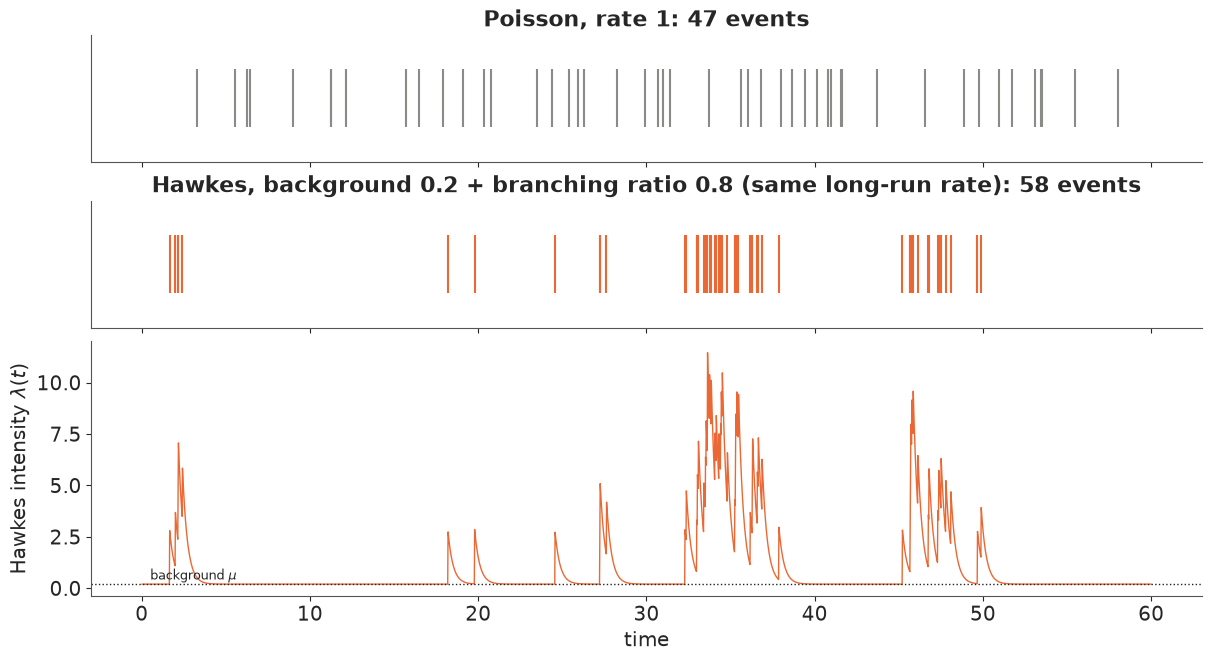

In [2]:
def G_omori(x, c, p):
    """int_0^x (s + c)^-p ds (Omori-Utsu), written to stay accurate near p = 1."""
    L = np.log1p(x / c)
    z = (1 - p) * L
    zs = np.where(np.abs(z) < 1e-8, 1.0, z)
    return c ** (1 - p) * L * np.where(np.abs(z) < 1e-8, 1 + z / 2, np.expm1(zs) / zs)


def Ginv_omori(y, c, p):
    """Inverse of G_omori: the delay x with G(x) = y."""
    if abs(1 - p) < 1e-8:
        return c * np.expm1(y / c)
    return c * np.expm1(np.log1p(y * (1 - p) * c ** (p - 1)) / (1 - p))


def G_exp(x, c):
    """int_0^x exp(-s / c) ds."""
    return -c * np.expm1(-x / c)


MMAX = 8.0  # Gutenberg-Richter truncation used throughout


def trunc_gr(rng, beta, lo, hi, size):
    """Gutenberg-Richter (exponential) magnitudes on [lo, hi]."""
    u = rng.uniform(size=size)
    return lo - np.log1p(-u * -np.expm1(-beta * (hi - lo))) / beta


def simulate_etas(par, hist_t, hist_m, T0, T1, Mc, rng, kernel="omori", max_events=200_000):
    """Events in (T0, T1]: background + offspring of the history + their cascades.
    par holds mu, K0, alpha, beta, c (and p for the Omori kernel); the kernel is K0 e^{alpha (m-Mc)} g."""
    mu, K0, al, beta, c = par["mu"], par["K0"], par["alpha"], par["beta"], par["c"]
    if kernel == "omori":
        Gf, Gi = (lambda x: G_omori(x, c, par["p"])), (lambda y: Ginv_omori(y, c, par["p"]))
    else:
        Gf, Gi = (lambda x: G_exp(x, c)), (lambda y: -c * np.log1p(-y / c))
    nb = rng.poisson(mu * (T1 - T0))
    gen_t, gen_m = rng.uniform(T0, T1, nb), trunc_gr(rng, beta, Mc, MMAX, nb)
    ht, hm = np.asarray(hist_t, float), np.asarray(hist_m, float)
    if ht.size:  # children of the history that fall inside (T0, T1]
        a, b = Gf(np.clip(T0 - ht, 0, None)), Gf(T1 - ht)
        k = rng.poisson(K0 * np.exp(al * (hm - Mc)) * (b - a))
        a, b, tp = np.repeat(a, k), np.repeat(b, k), np.repeat(ht, k)
        ch = tp + Gi(a + rng.uniform(size=tp.size) * (b - a))
        gen_t = np.concatenate([gen_t, ch])
        gen_m = np.concatenate([gen_m, trunc_gr(rng, beta, Mc, MMAX, ch.size)])
    out_t, out_m, exploded = [], [], False
    while gen_t.size:
        out_t.append(gen_t); out_m.append(gen_m)
        if sum(x.size for x in out_t) > max_events:
            exploded = True
            break
        b = Gf(T1 - gen_t)
        k = rng.poisson(K0 * np.exp(al * (gen_m - Mc)) * b)
        b, tp = np.repeat(b, k), np.repeat(gen_t, k)
        gen_t = tp + Gi(rng.uniform(size=tp.size) * b)
        gen_m = trunc_gr(rng, beta, Mc, MMAX, gen_t.size)
    if not out_t:
        return np.array([]), np.array([]), exploded
    tt, mm = np.concatenate(out_t), np.concatenate(out_m)
    o = np.argsort(tt)
    return tt[o], mm[o], exploded


# Poisson vs Hawkes with the same long-run rate (1 per unit time), exponential kernel
n_br, scale, T_demo = 0.8, 0.3, 60.0
hawkes_par = dict(mu=1.0 * (1 - n_br), K0=n_br / scale, alpha=0.0, beta=1.0, c=scale)
th, _, _ = simulate_etas(hawkes_par, [], [], 0.0, T_demo, 0.0, np.random.default_rng(1), kernel="exp")
tp_ = np.sort(np.random.default_rng(2).uniform(0, T_demo, np.random.default_rng(3).poisson(T_demo)))
grid = np.linspace(0, T_demo, 3000)
lam_h = hawkes_par["mu"] + hawkes_par["K0"] * np.where(
    grid[:, None] > th[None, :], np.exp(-(grid[:, None] - th[None, :]) / scale), 0).sum(1)

fig, axes = plt.subplots(3, 1, figsize=(12, 6.5), sharex=True, height_ratios=[1, 1, 2])
axes[0].eventplot(tp_, colors=GREY, lineoffsets=0, linelengths=0.8)
axes[0].set(yticks=[], title=f"Poisson, rate 1: {tp_.size} events")
axes[1].eventplot(th, colors=ORANGE, lineoffsets=0, linelengths=0.8)
axes[1].set(yticks=[], title=f"Hawkes, background 0.2 + branching ratio 0.8 (same long-run rate): {th.size} events")
axes[2].plot(grid, lam_h, color=ORANGE, lw=1)
axes[2].axhline(hawkes_par["mu"], color=INK, ls=":", lw=1)
axes[2].text(0.5, hawkes_par["mu"] + 0.2, "background $\\mu$", fontsize=9)
axes[2].set(xlabel="time", ylabel="Hawkes intensity $\\lambda(t)$");

Both processes have a long-run rate of one event per unit time. The Poisson events (grey) are
spread evenly; the Hawkes events (orange) come in **bursts** separated by long quiet spells, and
the intensity (bottom) jumps by $\kappa/\text{scale}$ at every event before relaxing to the
background. With a branching ratio of 0.8, only a fifth of the events are "spontaneous"; the rest
are descendants. Counts in windows of a Hawkes process are therefore overdispersed, which is
what E07's negative binomial absorbed without explaining.

## 2 · The Ridgecrest catalogue

In [3]:
data.describe("ridgecrest_2019_comcat")
cat = data.load("ridgecrest_2019_comcat").sort_values("time").reset_index(drop=True)
T64 = pd.Timestamp("2019-07-04 17:33:49", tz="UTC")
T71 = pd.Timestamp("2019-07-06 03:19:53", tz="UTC")
cat["t"] = (cat.time - T71).dt.total_seconds() / 86400  # days after the M7.1
t64 = (T64 - T71).total_seconds() / 86400
S0 = cat.t.min()                                         # catalogue start (2016-01-01)
i64 = int(np.argmin(np.abs(cat.t - t64))); i71 = int(np.argmin(np.abs(cat.t)))
print(cat.loc[[i64, i71], ["time", "mag", "magType", "latitude", "longitude", "depth"]])
print(f"{len(cat)} events M >= 2.0; magnitude types: {cat.magType.value_counts().to_dict()}")
print("events M >= 3.0 per period:",
      {"2016-01-01 to M6.4": int(((cat.t < t64) & (cat.mag >= 3)).sum()),
       "M6.4 to M7.1": int(((cat.t >= t64) & (cat.t < 0) & (cat.mag >= 3)).sum()),
       "first day after M7.1": int(((cat.t >= 0) & (cat.t < 1) & (cat.mag >= 3)).sum()),
       "days 1-8 after M7.1": int(((cat.t >= 1) & (cat.t < 8) & (cat.mag >= 3)).sum())})

ridgecrest_2019_comcat: Every earthquake of magnitude 2.0 or more in the box 35.2-36.4 N, 118.2-117.0 W, 2016-01-01 to 2019-12-31 (6,909 events), which contains the 2019 Ridgecrest, California sequence: the M6.4 of 2019-07-04 17:33:49 UTC and the M7.1 of 2019-07-06 03:19:53 UTC. Standard ComCat CSV columns: time (UTC, ISO 8601), latitude, longitude, depth (km), mag, magType (ml, mlr, mw...), nst, gap, dmin, rms, net, id, updated, place, type, horizontalError, depthError, magError, magNst, status, locationSource, magSource.
  source: USGS ANSS Comprehensive Earthquake Catalog (ComCat), FDSN event web service; Southern California Seismic Network solutions (network ci; 3 events from us; 1,877 events still status 'automatic'). US Government work, public domain. Downloaded 2026-09-28; ComCat revises events over time, so a fresh download can differ slightly - keep the cached file in data/.
  url:    https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2016-01-01&endtime=2020

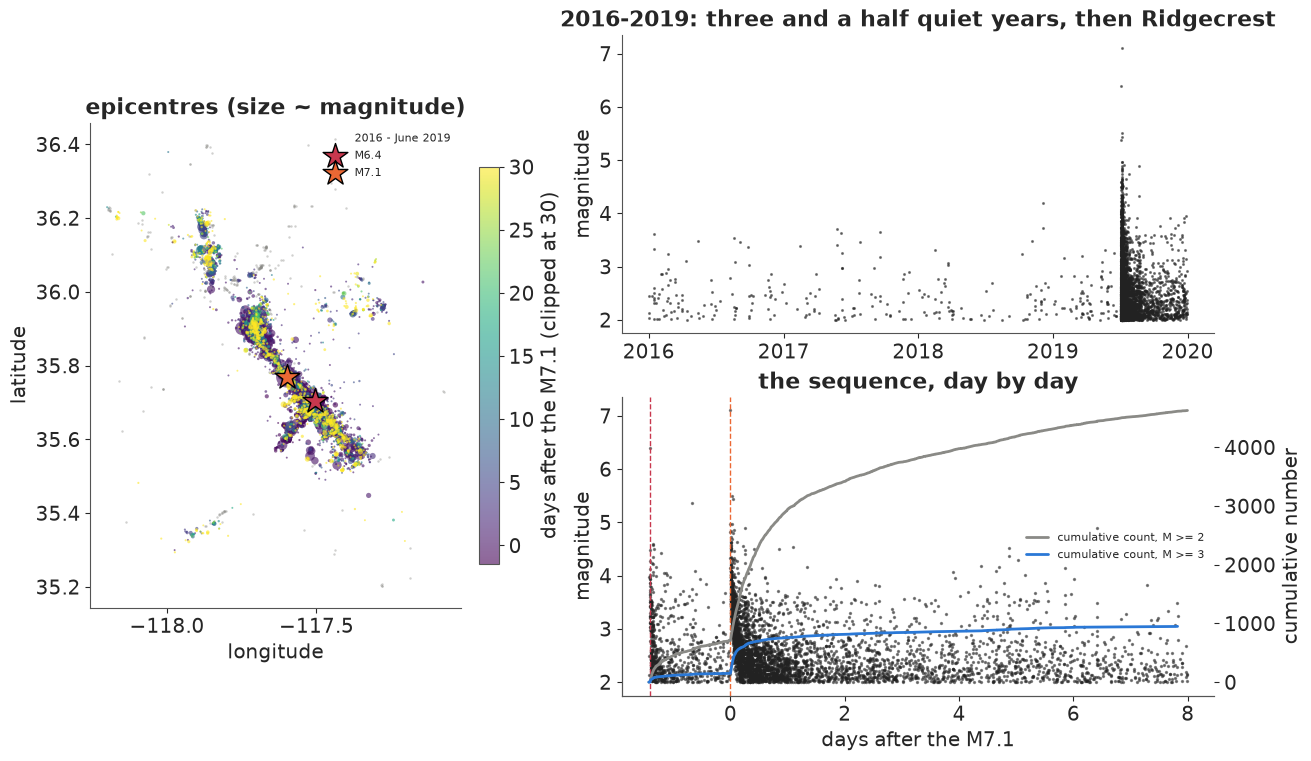

In [4]:
fig = plt.figure(figsize=(13, 7.5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.6])
ax = fig.add_subplot(gs[:, 0])
seq = cat[cat.t >= t64 - 1]
sc = ax.scatter(seq.longitude, seq.latitude, s=2 + 4 * (seq.mag - 2) ** 2.5, c=np.clip(seq.t, -2, 30),
                cmap="viridis", alpha=0.6, lw=0)
pre = cat[cat.t < t64 - 1]
ax.scatter(pre.longitude, pre.latitude, s=3, color=GREY, alpha=0.4, lw=0, label="2016 - June 2019")
for i, col, lab in [(i64, RED, "M6.4"), (i71, ORANGE, "M7.1")]:
    ax.scatter(cat.longitude[i], cat.latitude[i], marker="*", s=350, color=col, ec="k", label=lab, zorder=5)
ax.set(xlabel="longitude", ylabel="latitude", title="epicentres (size ~ magnitude)",
       aspect=1 / np.cos(np.deg2rad(35.8)), xticks=[-118.0, -117.5])
fig.colorbar(sc, ax=ax, shrink=0.6, label="days after the M7.1 (clipped at 30)")
ax.legend(fontsize=8, loc="upper right")
ax = fig.add_subplot(gs[0, 1])
ax.scatter(cat.time, cat.mag, s=1.5, color=INK, alpha=0.5)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set(ylabel="magnitude", title="2016-2019: three and a half quiet years, then Ridgecrest")
ax = fig.add_subplot(gs[1, 1])
z = cat[(cat.t > t64 - 1) & (cat.t < 8)]
ax.scatter(z.t, z.mag, s=2, color=INK, alpha=0.5)
ax2 = ax.twinx()
for m0, col in [(2.0, GREY), (3.0, BLUE)]:
    zz = z[z.mag >= m0]
    ax2.plot(zz.t, np.arange(1, len(zz) + 1), color=col, lw=2, label=f"cumulative count, M >= {m0:.0f}")
ax2.set_ylabel("cumulative number")
ax2.legend(fontsize=8, loc="center right")
ax.axvline(t64, color=RED, lw=1, ls="--"); ax.axvline(0, color=ORANGE, lw=1, ls="--")
ax.set(xlabel="days after the M7.1", ylabel="magnitude", title="the sequence, day by day");

Left: three and a half years of scattered background seismicity (grey), then the 2019 sequence,
which lines up along the NW-trending rupture of the M7.1 (the M6.4 broke a shorter fault
crossing it) and spreads north towards the Coso volcanic field. Right: the catalogue is dominated by
the sequence. The M6.4 (red dashed line) had its own aftershocks for 34 hours, then the M7.1
(orange) produced several hundred M3+ events in its first day. The cumulative curves bend over
the way Omori's law says: the rate falls roughly as $1/t$.

Magnitudes are a mix of local ($M_L$, `ml`/`mlr`) and moment magnitudes (`mw`, for the larger
events). We treat them as one scale, as operational forecasts do; it is one of the approximations
to keep in mind.

We work with **time only**. Space matters for where shaking will be felt, and a spatial ETAS is
a natural extension, but the forecast questions of this notebook (how many, how big, in the whole
region) are temporal.

## 3 · Magnitudes: Gutenberg-Richter, the b-value, and completeness

Above some magnitude, earthquake magnitudes follow the **Gutenberg-Richter law**:
$\log_{10} N(\ge M) = a - bM$, i.e. magnitudes above a threshold $M_c$ are exponential with rate
$\beta = b \ln 10$, and $b$ is close to 1 almost everywhere: each unit of magnitude is ten times
rarer. $M_c$, the **magnitude of completeness**, is where the catalogue stops missing events:
below it the network fails to detect or locate a growing fraction. The maximum-likelihood
$b$-value above $M_c$ is Aki's (1965) $\hat b = \log_{10} e / (\bar M - M_c)$ (with half a bin
width subtracted from $M_c$ for rounded magnitudes).

Completeness is not constant. **Right after a large earthquake**, seismograms are saturated by
overlapping arrivals and small events disappear under the coda of big ones: the catalogue is
incomplete up to magnitude 4 or more for the first minutes and hours. Helmstetter, Kagan &
Jackson (2006) proposed for California $M_c(t) = M_{\text{main}} - 4.5 - 0.75\log_{10} t$ with
$t$ in days after a mainshock of magnitude $M_{\text{main}}$. We check this against the data.

,events,Mc_maxcurv,n_M3,b_above_3
window,,,,
2016 to the M6.4,292,2.1,31,1.10
M7.1 + 0-15 min,63,4.0,63,0.40
15 min - 2.4 h,443,3.5,306,0.93
2.4 h - 1 day,1726,2.1,242,1.12
days 1-8,1686,2.1,191,1.06


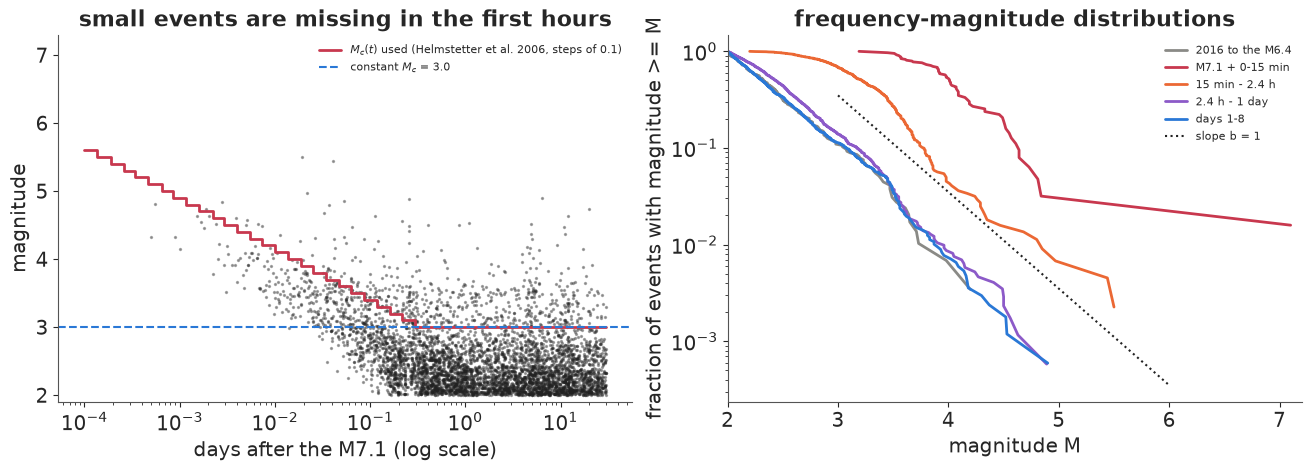

In [5]:
def aki_b(m, Mc, dm=0.01):
    m = np.asarray(m)
    m = m[m >= Mc - 1e-9]
    return np.log10(np.e) / (m.mean() - (Mc - dm / 2)), m.size


def mc_steps(S, T, Mc, mains, a=4.5, b=0.75, dm=0.1):
    """Piecewise-constant completeness Mc(t) = max(Mc, M - a - b log10(t - t_M)) on [S, T], rounded UP
    to dm. Returns (breaks, levels): levels[k] holds on [breaks[k], breaks[k+1])."""
    br = {S, T}
    for tm, M in mains:
        for lev in np.arange(Mc, M + 1e-9, dm):
            tt = tm + 10 ** ((M - a - lev) / b)
            if S < tt < T:
                br.add(tt)
        if S < tm < T:
            br.add(tm)
    br = np.array(sorted(br))
    mid = 0.5 * (br[:-1] + br[1:])
    lev = np.full(mid.shape, Mc)
    for tm, M in mains:
        after = mid > tm
        f = M - a - b * np.log10(np.where(after, mid - tm, 1.0))
        f = np.ceil(np.round(f / dm, 6)) * dm
        lev = np.where(after, np.maximum(lev, np.minimum(f, M)), lev)
    return br, lev


def mc_at(t, steps):
    br, lev = steps
    return lev[np.clip(np.searchsorted(br, t, side="left") - 1, 0, len(lev) - 1)]


MC = 3.0
MAINS = [(t64, 6.4), (0.0, 7.1)]
steps_demo = mc_steps(S0, 30.0, MC, MAINS)

bins_t = [(-1400, t64, "2016 to the M6.4"), (0, 0.01, "M7.1 + 0-15 min"), (0.01, 0.1, "15 min - 2.4 h"),
          (0.1, 1, "2.4 h - 1 day"), (1, 8, "days 1-8")]
rows = []
for lo, hi, lab in bins_t:
    mm = cat.mag[(cat.t >= lo) & (cat.t < hi)].to_numpy()
    h, e = np.histogram(mm, bins=np.arange(1.95, 7.25, 0.1))
    b3, n3 = aki_b(mm, 3.0)
    rows.append(dict(window=lab, events=mm.size, Mc_maxcurv=round(e[np.argmax(h)] + 0.05, 1),
                     n_M3=n3, b_above_3=round(b3, 2)))
display(pd.DataFrame(rows).set_index("window"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
aft = cat[(cat.t > 1e-4) & (cat.t < 30)]
ax.scatter(aft.t, aft.mag, s=2, color=INK, alpha=0.35)
tt_ = np.logspace(-4, np.log10(30), 400)
ax.step(tt_, mc_at(tt_, steps_demo), where="post", color=RED, lw=2, label="$M_c(t)$ used (Helmstetter et al. 2006, steps of 0.1)")
ax.axhline(3.0, color=BLUE, ls="--", lw=1.5, label="constant $M_c$ = 3.0")
ax.set(xscale="log", xlabel="days after the M7.1 (log scale)", ylabel="magnitude",
       title="small events are missing in the first hours", ylim=(1.9, 7.3))
ax.legend(fontsize=8)
ax = axes[1]
for (lo, hi, lab), col in zip(bins_t, [GREY, RED, ORANGE, PURPLE, BLUE]):
    mm = np.sort(cat.mag[(cat.t >= lo) & (cat.t < hi)].to_numpy())
    ax.plot(mm[::-1], np.arange(1, mm.size + 1) / mm.size, color=col, lw=2, label=lab)
xx = np.linspace(3, 6, 10)
ax.plot(xx, 0.35 * 10 ** (-(xx - 3.0)), color=INK, ls=":", lw=1.5, label="slope b = 1")
ax.set(yscale="log", xlabel="magnitude M", ylabel="fraction of events with magnitude >= M",
       title="frequency-magnitude distributions", xlim=(2, 7.2))
ax.legend(fontsize=8);

The table and figure agree. Before the sequence, the catalogue (which starts at M2.0) is complete
almost down to its floor and $b$ above 3 is about 1.1 (on only 31 events). In the **first 15
minutes after the M7.1** the most common recorded magnitude is 4, and the "b-value" above 3 is
0.4, not because the physics changed but because most M3s were never catalogued. Between 15
minutes and 2.4 hours the most common magnitude is still 3.5 and $b$ above 3 is 0.93. After that
the frequency-magnitude curves (right) are straight again down to about M2, and $b$ above 3 is
1.06-1.12.
The red step curve, the Helmstetter formula rounded up to 0.1, follows the lower edge of the
recorded magnitudes (left). It is conservative: it declares M3 complete only after about 7 hours.

A **constant** threshold of $M_c = 3$ looks perfectly safe on the whole-sequence distribution,
and that is the trap. Section 6 shows what it does to a model.

## 4 · The ETAS model, its likelihood and its priors

ETAS is a Hawkes process with magnitudes. For events above $M_c$,

$$\lambda(t) = \mu + \sum_{t_j < t} K_0\, e^{\alpha (m_j - M_c)}\,(t - t_j + c)^{-p},
\qquad m \sim \text{Gutenberg-Richter}(\beta),\ M_c \le m \le 8 .$$

- the **Omori-Utsu kernel** $(t + c)^{-p}$: a power law with a short delay $c$ that keeps the rate
  finite at $t = 0$, decaying with exponent $p$ (about 1);
- **productivity** $e^{\alpha(m - M_c)}$: an event one magnitude unit bigger has $e^\alpha$ times
  more direct aftershocks ($\alpha \approx 2$, i.e. about 7 times);
- magnitudes are independent of the past with $\beta = b \ln 10$.

Instead of $K_0$ we sample something with units we can reason about: $k_1$, **the expected number
of direct aftershocks above $M_c$ within one year of an $M_c$ event**, so
$K_0 = k_1 / \int_0^{365}(s + c)^{-p} ds$.

**The likelihood.** For events $t_1 < \dots < t_n$ with magnitudes $m_i$ observed in $[S, T]$,

$$\log L = \sum_i \log \lambda(t_i) - \int_S^T \lambda(t)\,dt + \sum_i \log f_{GR}(m_i),$$

and the integral (the **compensator**) is in closed form, because each event's kernel integrates
to $G(x) = \int_0^x (s + c)^{-p} ds = \frac{(x + c)^{1-p} - c^{1-p}}{1 - p}$:

$$\int_S^T \lambda = \mu (T - S) + \sum_j K_0 e^{\alpha(m_j - M_c)} \left[G(T - t_j) - G(\max(S - t_j, 0))\right].$$

That is $O(n)$. The first sum is the expensive part: $\lambda(t_i)$ involves every earlier event,
$O(n^2)$ in total.

**Branching ratio.** One event of magnitude $m$ has on average $K_0 e^{\alpha(m-M_c)} G(\infty)$
children, where $G(\infty) = c^{1-p}/(p-1)$ is finite only for $p > 1$. Averaging over the
Gutenberg-Richter distribution,

$$n = K_0\, G(\infty)\ \mathbb{E}\!\left[e^{\alpha (m - M_c)}\right], \qquad
\mathbb{E}\!\left[e^{\alpha (m - M_c)}\right] = \frac{\beta}{\beta - \alpha}\,
\frac{1 - e^{-(\beta - \alpha)(M_{\max} - M_c)}}{1 - e^{-\beta (M_{\max} - M_c)}} .$$

When $\alpha$ approaches $\beta$ the expectation is dominated by the rare largest events and
grows with $M_{\max}$ (Helmstetter & Sornette 2002): productivity and the b-value compete, and
that competition decides whether the model is stable.

**Priors**, per day and for $M_c = 3$ in this box:

| parameter | prior | why |
|---|---|---|
| $\mu$ | LogNormal(log 0.02, 1) | a few M3+ a year in a quiet year; median 7 per year |
| $\log c$ (days) | Normal(log 0.01, 1.5) | $c$ from about a minute to a few hours |
| $p$ | Normal(1.1, 0.15) | Omori exponents are mostly 0.9-1.3 |
| $\alpha$ | Normal(1.8, 0.5) | productivity grows 3-15-fold per magnitude unit |
| $b$ | Normal(1, 0.3), truncated at 0.3 | b-values are close to 1 |
| $k_1$ | LogNormal(log 0.1, 1) | an M3 has on average about 0.1 direct M3+ aftershocks within a year |

Before fitting, what do these priors say about the question we care about? The next cell draws
from the prior the **expected number of direct M3+ aftershocks of an M7.1 in its first day**, and
the branching ratio.

prior: median direct day-1 aftershocks of an M7.1 = 76 (90%: 2 - 3461); P(n >= 1 or p <= 1) = 0.59


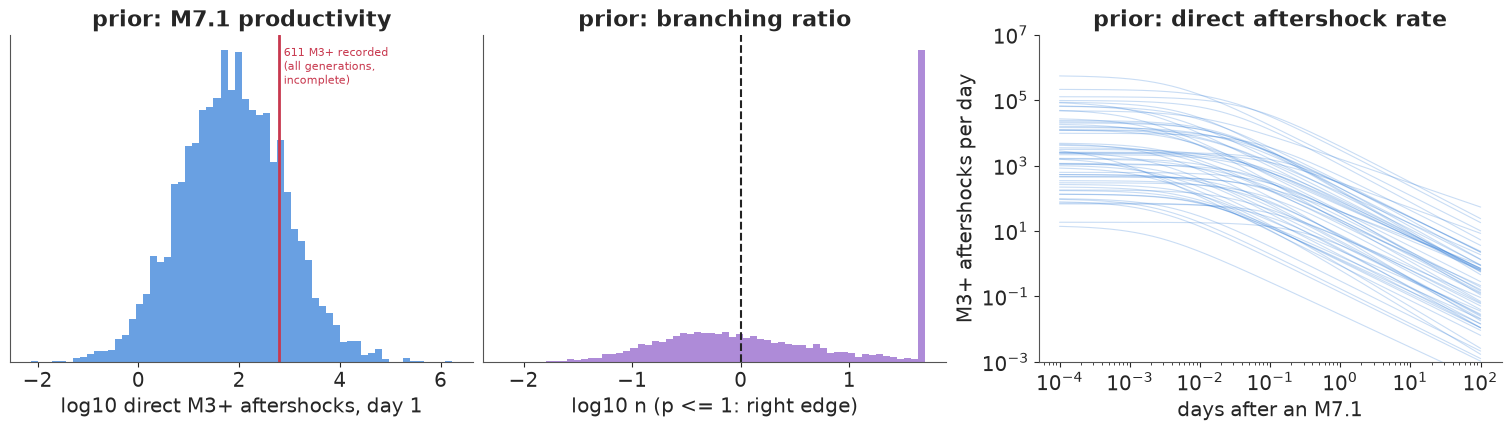

In [6]:
PRIORS = dict(mu=(np.log(0.02), 1.0), log_c=(np.log(0.01), 1.5), p=(1.1, 0.15),
              alpha=(1.8, 0.5), b=(1.0, 0.3), k1=(np.log(0.1), 1.0))


def branching_ratio(k1, c, p, alpha, beta, Mc=MC):
    """Mean number of direct children of an average event (inf when p <= 1)."""
    K0 = k1 / G_omori(365.0, c, p)
    G_inf = np.where(p > 1, c ** (1 - p) / np.where(p > 1, p - 1, 1), np.inf)
    d = beta - alpha
    span = MMAX - Mc
    Em = np.where(np.abs(d) > 1e-9, beta / np.where(np.abs(d) > 1e-9, d, 1) * -np.expm1(-d * span), beta * span)
    Em = Em / -np.expm1(-beta * span)
    return K0 * G_inf * Em


prng = np.random.default_rng(RANDOM_SEED)
npr = 4000
pr = dict(mu=np.exp(prng.normal(*PRIORS["mu"], npr)), c=np.exp(prng.normal(*PRIORS["log_c"], npr)),
          p=prng.normal(*PRIORS["p"], npr), alpha=prng.normal(*PRIORS["alpha"], npr),
          b=stats.truncnorm.rvs((0.3 - 1) / 0.3, np.inf, 1, 0.3, size=npr, random_state=prng),
          k1=np.exp(prng.normal(*PRIORS["k1"], npr)))
pr["beta"] = pr["b"] * np.log(10)
pr["K0"] = pr["k1"] / G_omori(365.0, pr["c"], pr["p"])
direct_day1 = pr["K0"] * np.exp(pr["alpha"] * (7.1 - MC)) * G_omori(1.0, pr["c"], pr["p"])
n_prior = branching_ratio(pr["k1"], pr["c"], pr["p"], pr["alpha"], pr["beta"])
obs_day1 = int(((cat.t > 0) & (cat.t < 1) & (cat.mag >= MC)).sum())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].hist(np.log10(direct_day1), bins=60, color=BLUE, alpha=0.7)
axes[0].axvline(np.log10(obs_day1), color=RED, lw=2)
axes[0].text(np.log10(obs_day1) + 0.1, axes[0].get_ylim()[1] * 0.85,
             f"{obs_day1} M3+ recorded\n(all generations,\nincomplete)", color=RED, fontsize=8)
axes[0].set(xlabel="log10 direct M3+ aftershocks, day 1", yticks=[],
            title="prior: M7.1 productivity")
nn = np.where(np.isfinite(n_prior), n_prior, 50)
axes[1].hist(np.log10(np.clip(nn, 1e-3, 50)), bins=60, color=PURPLE, alpha=0.7)
axes[1].axvline(0, color=INK, ls="--")
axes[1].set(xlabel="log10 n (p <= 1: right edge)", yticks=[],
            title="prior: branching ratio")
tt_ = np.logspace(-4, 2, 200)
for i in range(60):
    axes[2].plot(tt_, pr["K0"][i] * np.exp(pr["alpha"][i] * 4.1) * (tt_ + pr["c"][i]) ** -pr["p"][i],
                 color=BLUE, alpha=0.25, lw=0.8)
axes[2].set(xscale="log", yscale="log", xlabel="days after an M7.1", ylabel="M3+ aftershocks per day",
            title="prior: direct aftershock rate", ylim=(1e-3, 1e7))
print(f"prior: median direct day-1 aftershocks of an M7.1 = {np.median(direct_day1):.0f} "
      f"(90%: {np.quantile(direct_day1, 0.05):.0f} - {np.quantile(direct_day1, 0.95):.0f}); "
      f"P(n >= 1 or p <= 1) = {np.mean(~(n_prior < 1)):.2f}");

The prior is wide but not absurd: the expected number of direct M3+ aftershocks of an M7.1 in its
first day spans about three orders of magnitude (90%: 2 to about 3,500, median 76), with the 611
M3+ events actually recorded (which include later generations and miss the first hours'
events) in its upper half. The prior is **not** confident about stability: about 60% of the
draws have $n \ge 1$ or $p \le 1$ (middle; the right-hand spike is $p \le 1$). We do not force
$n < 1$ - a short, intense sequence can genuinely look near-critical - but we will watch it,
because it decides how the forecast's tail behaves.

## 5 · Computing the likelihood: $O(n^2)$, $O(n)$ and a mixture of exponentials

The double sum in $\sum_i \log\lambda(t_i)$ touches every pair of events. With about 800 M3+
events up to one day after the M7.1 that is 300,000 pairs per gradient evaluation, and NUTS needs
tens of thousands of gradients.

For an **exponential kernel** $e^{-(t - t_j)/c}$ there is a classic $O(n)$ recursion: with
$A_i = \sum_{j<i} w_j e^{-(t_i - t_j)/c}$,

$$A_i = e^{-(t_i - t_{i-1})/c}\,(A_{i-1} + w_{i-1}),$$

a one-line `pytensor.scan`. A power law has no such recursion, **but it is a mixture of
exponentials**:

$$(x + c)^{-p} = \frac{1}{\Gamma(p)}\int_0^\infty s^{p-1} e^{-s c}\, e^{-s x}\, ds
\approx \sum_{k=1}^{K} w_k(c, p)\, e^{-s_k x}, \qquad w_k = \frac{h\, s_k^{p} e^{-s_k c}}{\Gamma(p)},$$

with nodes $s_k = e^{u_k}$ on a fixed grid in $u = \log s$ of step $h$ (the trapezoid rule, which
converges very fast for this smooth, doubly decaying integrand). The nodes do not depend on the
parameters, so the recursion runs on a $K$-vector of decaying states with **fixed** decay factors
$e^{-s_k (t_i - t_{i-1})}$, and $c$ and $p$ enter only through the weights. That is $O(nK)$ with
$K = 79$ nodes covering delays from seconds to decades. The same states give the compensator
correction that section 6 needs.

Below: the model-building function (used for every fit in this notebook), an exact $O(n^2)$
version, and timings of one log-density + gradient evaluation.

In [7]:
U_NODES = np.arange(-25.0, 14.0 + 1e-9, 0.5)  # log s nodes: 1/s from ~1e-6 to 7e10 days


def pt_G(x, c, p):
    L = pt.log1p(x / c)
    z = (1 - p) * L
    zs = pt.switch(pt.abs(z) < 1e-8, 1.0, z)
    return c ** (1 - p) * L * pt.switch(pt.abs(z) < 1e-8, 1 + z / 2, pt.expm1(zs) / zs)


def etas_model(t, m, Mc, S, T, steps=None, kernel="omori", method="soe", priors=PRIORS):
    """Temporal ETAS (kernel="omori") or exponential Hawkes (kernel="exp") with GR magnitudes.
    t: event times (days, sorted, all <= T), m: magnitudes >= Mc. Every event is a parent; the
    likelihood covers the events in [S, T] with m >= Mc(t), where steps = (breaks, levels) is a
    piecewise-constant completeness threshold (None: constant Mc).
    method: "soe" (mixture-of-exponentials recursion) or "exact" (all pairs)."""
    t, m = np.asarray(t, float), np.asarray(m, float)
    steps = steps if steps is not None else (np.array([S, T]), np.array([Mc]))
    br, lev = steps
    lo, hi = br[:-1], br[1:]
    tgt = np.flatnonzero((t >= S) & (t <= T) & (m >= mc_at(t, steps) - 1e-9))
    dm = m - Mc
    with pm.Model() as model:
        mu = pm.LogNormal("mu", *priors["mu"])
        log_c = pm.Normal("log_c", *priors["log_c"])
        c = pm.Deterministic("c", pt.exp(log_c))
        alpha = pm.Normal("alpha", *priors["alpha"])
        b = pm.TruncatedNormal("b", *priors["b"], lower=0.3)
        beta = b * np.log(10)
        k1 = pm.LogNormal("k1", *priors["k1"])
        ea = pt.exp(alpha * dm)                                    # productivity of every event
        if kernel == "omori":
            p = pm.Normal("p", *priors["p"])
            Gf = lambda x: pt_G(x, c, p)
        else:
            Gf = lambda x: -c * pt.expm1(-x / c)
        K0 = pm.Deterministic("K0", k1 / Gf(365.0))
        # ---- sum over parents for every event: lambda(t_i) = mu + K0 * trig_i
        if method == "exact":
            I, J = np.tril_indices(len(t), -1)                     # (child, parent) pairs
            keep = np.isin(I, tgt)
            I, J = I[keep], J[keep]
            x = t[I] - t[J]
            g = (x + c) ** (-p) if kernel == "omori" else pt.exp(-x / c)
            trig = pt.zeros(len(t))[I].inc(ea[J] * g)[tgt]
        elif kernel == "omori":
            sk = np.exp(U_NODES)
            decay = np.exp(-np.outer(np.diff(t), sk))              # fixed: (n - 1) x K
            wk = pt.exp(p * U_NODES - sk * c - pt.gammaln(p) + np.log(U_NODES[1] - U_NODES[0]))
            A = pytensor.scan(lambda dec, e, a: dec * (a + e), sequences=[pt.as_tensor(decay), ea[:-1]],
                              outputs_info=[pt.zeros(len(sk))], return_updates=False)
            A = pt.concatenate([pt.zeros((1, len(sk))), A], axis=0)  # states just before each event
            trig = (A @ wk)[tgt]
        else:
            A = pytensor.scan(lambda dec, e, a: dec * (a + e), sequences=[pt.exp(-np.diff(t) / c), ea[:-1]],
                              outputs_info=[pt.zeros(())], return_updates=False)
            trig = pt.concatenate([pt.zeros(1), A])[tgt]
        lam = mu + K0 * trig
        # ---- compensator of the DETECTABLE events: int q(t) lambda(t) dt, q = P(M >= Mc(t) | M >= Mc)
        Z = -pt.expm1(-beta * (MMAX - Mc))
        q = (pt.exp(-beta * (lev - Mc)) - pt.exp(-beta * (MMAX - Mc))) / Z
        comp = mu * (q * (hi - lo)).sum() + K0 * (ea * (Gf(np.clip(T - t, 0, None))
                                                        - Gf(np.clip(S - t, 0, None)))).sum()
        inc = np.flatnonzero((lev > Mc + 1e-9) & (hi > lo))      # incomplete steps: subtract (1 - q)
        if inc.size and kernel == "omori" and method == "soe":
            # parents born before the step: integrate their exponential mixture from the scan state
            first = np.searchsorted(t, lo[inc], side="left")
            last = np.maximum(first - 1, 0)
            dec_lo = np.exp(-np.outer(lo[inc] - t[last], sk)) * (first > 0)[:, None]
            integ = -np.expm1(-np.outer(hi[inc] - lo[inc], sk)) / sk
            old = ((A[last] + ea[last][:, None]) * dec_lo * integ) @ wk
            # parents born inside the step: exact
            kin = np.clip(np.searchsorted(br, t, side="right") - 1, 0, len(lev) - 1)
            jin = np.flatnonzero(np.isin(kin, inc))
            pos = np.searchsorted(inc, kin[jin])
            new = pt.zeros(inc.size)[pos].inc(ea[jin] * Gf(hi[kin[jin]] - t[jin]))
            comp = comp - K0 * ((1 - q[inc]) * (old + new)).sum()
        elif inc.size:
            ks, js = np.nonzero((lev[:, None] > Mc + 1e-9) & (t[None, :] < hi[:, None]) & (hi > lo)[:, None])
            Gkj = Gf(np.clip(hi[ks] - t[js], 0, None)) - Gf(np.clip(lo[ks] - t[js], 0, None))
            comp = comp - K0 * ((1 - q[ks]) * ea[js] * Gkj).sum()
        pm.Potential("time_loglik", pt.log(lam).sum() - comp)
        pm.Potential("magnitude_loglik", (pt.log(beta) - beta * dm[tgt] - pt.log(Z)).sum())
    return model, tgt

Two details in there are the fix of section 6 and are explained there: the likelihood covers only
events above a time-varying threshold $M_c(t)$, and the compensator is weighted by the probability
$q(t)$ that an event is above it. For now, time the three ways of computing the same thing.

In [8]:
T_B = 1.0                                   # forecast origin: 24 h after the M7.1
evB = cat[(cat.mag >= MC) & (cat.t <= T_B)]
steps_B = mc_steps(S0, T_B, MC, MAINS)
test_point = dict(mu_log__=np.log(0.02), log_c=np.log(0.003), p=1.2, alpha=2.2,
                  b_interval__=0.5, k1_log__=np.log(0.08))


def time_dlogp(model, n_rep=60):
    ip = model.initial_point()
    ip.update({k: v for k, v in test_point.items() if k in ip})
    f, lp = model.compile_dlogp(), model.compile_logp()
    f(ip)
    t0 = time.perf_counter()
    for _ in range(n_rep):
        f(ip)
    return (time.perf_counter() - t0) / n_rep * 1000, float(lp(ip))


timing = []
for label, kern, meth in [("Omori, exact pairs O(n^2)", "omori", "exact"),
                          ("Omori, mixture of 79 exponentials O(nK)", "omori", "soe"),
                          ("exponential, exact pairs O(n^2)", "exp", "exact"),
                          ("exponential, recursion O(n)", "exp", "soe")]:
    mod, tg = etas_model(evB.t.values, evB.mag.values, MC, S0, T_B, steps=steps_B, kernel=kern, method=meth)
    ms, lp = time_dlogp(mod)
    timing.append(dict(likelihood=label, ms_per_gradient=round(ms, 2), logp=round(lp, 5)))
display(pd.DataFrame(timing).set_index("likelihood"))
print(f"{len(evB)} events (parents), {len(tg)} in the likelihood; "
      f"{len(evB) * (len(evB) - 1) // 2:,} event pairs")

,ms_per_gradient,logp
likelihood,,
"Omori, exact pairs O(n^2)",3.97,1407.57631
"Omori, mixture of 79 exponentials O(nK)",0.41,1407.57630
"exponential, exact pairs O(n^2)",0.96,854.63103
"exponential, recursion O(n)",0.30,854.63103


790 events (parents), 412 in the likelihood; 311,655 event pairs


The mixture of exponentials reproduces the exact log-density to about $10^{-5}$ (compare the two
Omori rows) and is about nine times faster per gradient (0.4 vs 3.6 ms). For the exponential
kernel the recursion is three times faster than its pair sum. The gap widens with the catalogue: the pair sum grows as $n^2$ and the
recursion as $n$. Every Omori fit below uses the mixture.

## 6 · The failure, with a known truth: the missing aftershocks of the first hours

Section 3 showed that after the M7.1 the catalogue misses most M3s for hours. A model fitted to
all M3+ events as if the catalogue were complete sees too few events early on, relative to
later. It will explain the shortfall in the only ways it can: a **larger $c$** (the Omori curve
flattens at early times), a different $p$, and - because the missing events are the small ones -
a **smaller b-value**, i.e. more large earthquakes. The last one goes straight into the forecast
probability of a damaging aftershock.

**The fix** keeps the model for the true process and adds a model of the observation:

- an event of magnitude $m$ at time $t$ enters the likelihood only if $m \ge M_c(t)$ (the step
  function of section 3);
- the intensity of *recorded* events is $q(t)\lambda(t)$ with
  $q(t) = P(M \ge M_c(t) \mid M \ge M_c)$ from Gutenberg-Richter, so the compensator becomes
  $\int q(t)\lambda(t)\,dt$ - still closed form because $q$ is piecewise constant;
- the magnitude density of a recorded event is Gutenberg-Richter conditioned on $m \ge M_c(t)$.
  The factor $q(t)$ cancels between the two parts, which is why the code adds only the plain
  $\log\lambda$ and $\log f_{GR}$ terms and changes only the compensator.

Every catalogued event still acts as a parent. What the fix cannot do is give the model the
parents that were never recorded. We accept that approximation and test it below (a full
treatment would model the detection probability of each event, e.g. Omi et al. 2013).

We first test it where the answer is known: simulate a sequence from ETAS with fixed parameters,
starting with an M7.1 at $t=0$ after 3.5 years of background, and delete what the network would
have missed. Section 3 suggested that the network actually does about 0.4 magnitude units better
than the conservative formula, so events below $M_c(t) - 0.4$ are deleted (they are lost as data
*and* as parents), while the fit uses the conservative $M_c(t)$. Three fits: naive, $M_c(t)$, and
for reference $M_c(t)$ on the complete simulated catalogue (every parent known).

In [9]:
truth = dict(mu=0.02, c=0.002, p=1.15, alpha=2.2, b=1.05, k1=0.07)
truth["beta"] = truth["b"] * np.log(10)
truth["K0"] = truth["k1"] / G_omori(365.0, truth["c"], truth["p"])
T_SIM = 1.0
ts, ms_, _ = simulate_etas(truth, [0.0], [7.1], S0, T_SIM, MC, np.random.default_rng(651))
ts, ms_ = np.append(ts, 0.0), np.append(ms_, 7.1)
o = np.argsort(ts); ts, ms_ = ts[o], ms_[o]
steps_sim = mc_steps(S0, T_SIM, MC, [(0.0, 7.1)])            # what the analyst assumes
seen = ms_ >= mc_at(ts, mc_steps(S0, T_SIM, MC, [(0.0, 7.1)], a=4.9)) - 1e-9  # what the network recorded
in_lik = seen & (ms_ >= mc_at(ts, steps_sim) - 1e-9)
xb = ms_[in_lik] - mc_at(ts[in_lik], steps_sim)
print(f"simulated: {ts.size} events M >= 3 (background + cascade of the M7.1); recorded {seen.sum()} "
      f"(all deletions in the first {ts[~seen].max() * 24:.1f} h); {in_lik.sum()} above the assumed Mc(t)")
print(f"b-value of the events above Mc(t) in this sample (MLE): {np.log10(np.e) / xb.mean():.2f} (truth 1.05)")

VARS = ["mu", "c", "p", "alpha", "b", "k1"]
fits_sim = {}
for label, st, keep in [("naive (constant Mc = 3)", None, seen), ("time-varying Mc(t)", steps_sim, seen),
                        ("Mc(t), complete catalogue", steps_sim, np.ones_like(seen))]:
    mod, _ = etas_model(ts[keep], ms_[keep], MC, S0, T_SIM, steps=st)
    fits_sim[label] = pm.sample(model=mod, random_seed=RANDOM_SEED, progressbar=False)
    ss = fits_sim[label].sample_stats
    print(f"{label:25s}: divergences {int(ss['diverging'].sum())}, max r_hat "
          f"{float(az.rhat(fits_sim[label], var_names=VARS).to_dataset().to_dataarray().max()):.3f}")

simulated: 788 events M >= 3 (background + cascade of the M7.1); recorded 427 (all deletions in the first 1.9 h); 280 above the assumed Mc(t)
b-value of the events above Mc(t) in this sample (MLE): 1.03 (truth 1.05)


naive (constant Mc = 3)  : divergences 0, max r_hat 1.004


time-varying Mc(t)       : divergences 0, max r_hat 1.004


Mc(t), complete catalogue: divergences 0, max r_hat 1.008


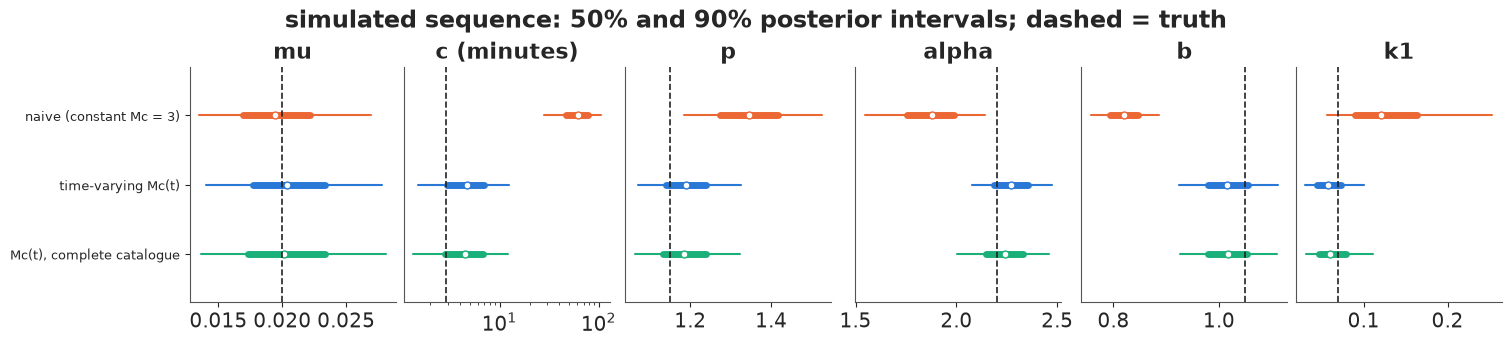

In [10]:
def interval_panel(fits, truth=None, colors=(ORANGE, BLUE, AQUA), title=""):
    fig, axes = plt.subplots(1, 6, figsize=(15, 2.6 + 0.25 * len(fits)))
    labels = list(fits)
    for ax, v in zip(axes, VARS):
        for k, lab in enumerate(labels):
            if v not in fits[lab].posterior:
                continue
            x = fits[lab].posterior[v].values.ravel()
            if v == "c":
                x = x * 24 * 60
            q5, q25, q50, q75, q95 = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
            y = len(labels) - 1 - k
            ax.plot([q5, q95], [y, y], color=colors[k], lw=1.5)
            ax.plot([q25, q75], [y, y], color=colors[k], lw=5)
            ax.plot(q50, y, "o", color="white", mec=colors[k], ms=5)
        if truth is not None:
            tv = truth[v] * (24 * 60 if v == "c" else 1)
            ax.axvline(tv, color=INK, ls="--", lw=1.2)
        ax.set(title=v + (" (minutes)" if v == "c" else ""), yticks=[], ylim=(-0.7, len(labels) - 0.3))
        if v == "c":
            ax.set_xscale("log")
    axes[0].set_yticks(range(len(labels))[::-1], labels, fontsize=9)
    fig.suptitle(title)
    return fig


interval_panel(fits_sim, truth, title="simulated sequence: 50% and 90% posterior intervals; dashed = truth");

With the truth known, the failure is plain. Fitted as if complete, the recorded catalogue gives a
$c$ of about an hour instead of 3 minutes, a b-value well below the true 1.05, a steeper $p$ and a
lower $\alpha$: the deleted events were small ones in the first hours, exactly where $c$ and $b$
are learned. The $M_c(t)$ fit, on the same recorded events, covers the truth with its 90%
interval for every parameter, and is almost indistinguishable from the same model fitted to the
complete catalogue (bottom row): here, the 361 parents that were never recorded hardly matter. This
is one simulated sequence, so it shows the direction and size of the bias, not a calibration
rate; with other seeds the $M_c(t)$ posterior follows the b-value of the particular sample
(printed above), which can differ from the generating 1.05 by a few hundredths.

## 7 · Fitting Ridgecrest: naive, fixed, and an exponential-kernel Hawkes

Now the real catalogue, up to the forecast origin **24 hours after the M7.1**: every M3+ event since
2016 (the three and a half quiet years pin down $\mu$), the M6.4 and its 34 hours of aftershocks, and the
first day after the M7.1. Three models:

1. **naive**: ETAS with a constant $M_c = 3$;
2. **ETAS with $M_c(t)$**: the fix, completeness steps after both the M6.4 and the M7.1;
3. **exponential Hawkes with $M_c(t)$**: same data model, exponential instead of power-law decay.

In [11]:
fits = {}
for label, st, kern in [("naive ETAS (constant Mc)", None, "omori"),
                        ("ETAS with Mc(t)", steps_B, "omori"),
                        ("exponential Hawkes, Mc(t)", steps_B, "exp")]:
    mod, tg = etas_model(evB.t.values, evB.mag.values, MC, S0, T_B, steps=st, kernel=kern)
    t0 = time.perf_counter()
    fits[label] = pm.sample(model=mod, random_seed=RANDOM_SEED, progressbar=False)
    ss = fits[label].sample_stats
    vv = [v for v in VARS if v in fits[label].posterior]
    print(f"{label:28s} {len(tg):4d} events in likelihood | {time.perf_counter() - t0:5.1f} s | "
          f"divergences {int(ss['diverging'].sum())} | max r_hat "
          f"{float(az.rhat(fits[label], var_names=vv).to_dataset().to_dataarray().max()):.3f} | "
          f"min bulk ESS {float(az.ess(fits[label], var_names=vv).to_dataset().to_dataarray().min()):.0f}")
main = fits["ETAS with Mc(t)"]
print(f"nutpie warm-up steps: {main.posterior.attrs.get('tuning_steps')}")
display(az.summary(main, var_names=VARS + ["K0"], round_to=4))

naive ETAS (constant Mc)      790 events in likelihood |  17.3 s | divergences 0 | max r_hat 1.007 | min bulk ESS 712


ETAS with Mc(t)               412 events in likelihood |  14.5 s | divergences 0 | max r_hat 1.003 | min bulk ESS 708


exponential Hawkes, Mc(t)     412 events in likelihood |   7.8 s | divergences 0 | max r_hat 1.005 | min bulk ESS 377
nutpie warm-up steps: 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.0201,0.0041,0.0140,0.0270,3706.0082,2846.3390,1.0018,0.0001,0.0001
c,0.0014,0.0009,0.0005,0.0031,2213.8840,2025.0211,1.0011,0.0000,0.0000
p,1.1649,0.0536,1.0845,1.2535,2377.5572,2262.8374,1.0002,0.0011,0.0009
alpha,2.2945,0.1210,2.0947,2.4803,708.3132,1069.1197,1.0035,0.0046,0.0026
b,1.0694,0.0480,0.9937,1.1452,2587.3996,2590.4738,1.0014,0.0009,0.0008
k1,0.0748,0.0251,0.0417,0.1190,723.8634,1087.1082,1.0033,0.0009,0.0007
K0,0.0047,0.0017,0.0024,0.0078,762.5188,1162.8051,1.0029,0.0001,0.0000


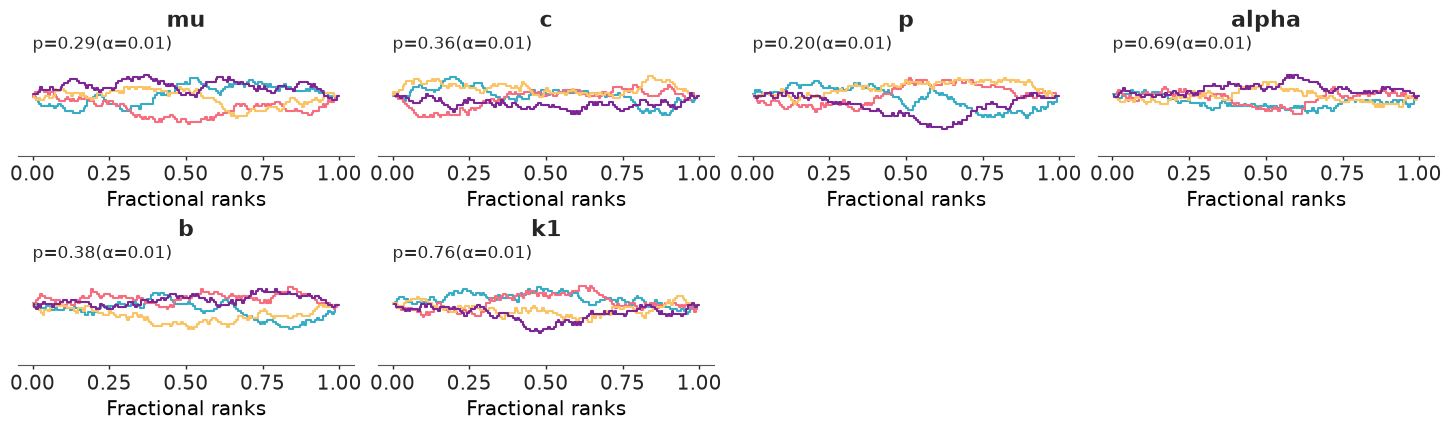

In [12]:
az.plot_rank(main.isel(draw=slice(None, None, 6)), var_names=VARS);  # thinned to about the ESS

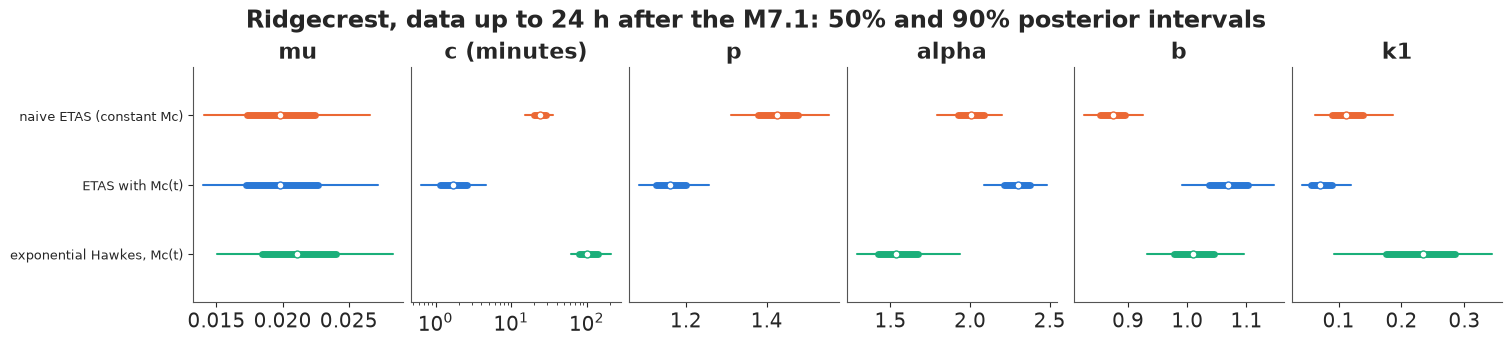

In [13]:
interval_panel(fits, title="Ridgecrest, data up to 24 h after the M7.1: 50% and 90% posterior intervals");

All three fits are clean: no divergences, r_hat at most 1.01, bulk ESS in the hundreds or more,
and the rank plots of the main fit (thinned to about its ESS) are flat. **Clean is not the same as
right.** The naive model reproduces the simulated failure on real data: $c$ of about 25 minutes
instead of about 2, a steeper decay ($p \approx 1.43$ vs 1.17), a lower $\alpha$ (2.0 vs 2.3) and
a b-value of about 0.87 against 1.07 for the $M_c(t)$ model. A difference of 0.2 in $b$ is a
factor $10^{0.2 \times 2} \approx 2.5$ in the predicted share of M5+ among M3+ events.

The exponential Hawkes model cannot represent a decay that spans minutes to days with one time
scale: its "memory" $c$ settles near an hour and a half, and $\alpha$ drops to about 1.5. The next
section asks whether the models actually describe the data.

## 8 · Goodness of fit with the time-rescaling theorem

If $\Lambda(t) = \int_S^t \lambda$ is the true compensator, the **transformed times**
$\tau_i = \Lambda(t_i)$ form a Poisson process of rate 1 (the time-rescaling theorem; Ogata 1988,
Brown et al. 2002). So the gaps $\tau_i - \tau_{i-1}$ should be Exponential(1) and
$u_i = 1 - e^{-(\tau_i - \tau_{i-1})}$ uniform; and the count of events against $\tau$ should
follow the diagonal. It is a posterior predictive check that needs no simulation: we compute it
for 200 posterior draws of each model, in NumPy (exact pair sums), with the compensator of the
*recorded* events, $\int q\lambda$.

In [14]:
def params_list(idata, n, seed, kernel="omori"):
    post = idata.posterior
    names = ["mu", "c", "alpha", "b", "K0"] + (["p"] if kernel == "omori" else [])
    arr = {k: post[k].values.ravel() for k in names}
    arr["beta"] = arr["b"] * np.log(10)
    idx = np.random.default_rng(seed).choice(arr["mu"].size, n, replace=False)
    return [{k: v[i] for k, v in arr.items()} for i in idx]


def Gk(x, par, kernel):
    x = np.clip(x, 0, None)
    return G_omori(x, par["c"], par["p"]) if kernel == "omori" else G_exp(x, par["c"])


def g_kernel(x, par, kernel):
    xs = np.where(x > 0, x, 1.0)
    g = (xs + par["c"]) ** -par["p"] if kernel == "omori" else np.exp(-xs / par["c"])
    return np.where(x > 0, g, 0.0)


def intensity(tau, t, m, par, kernel="omori", Mc=MC):
    """lambda(tau) for M >= Mc events; parents are events strictly before tau."""
    ea = np.exp(par["alpha"] * (m - Mc))
    return par["mu"] + par["K0"] * (g_kernel(tau[:, None] - t[None, :], par, kernel) * ea).sum(1)


def compensator(tau, t, m, S, steps, par, kernel="omori", Mc=MC):
    """int_S^tau q(s) lambda(s) ds at sorted times tau (recorded events only)."""
    br, lev = steps
    be = par["beta"]
    q = (np.exp(-be * (lev - Mc)) - np.exp(-be * (MMAX - Mc))) / -np.expm1(-be * (MMAX - Mc))
    pts = np.union1d(tau, br[(br > S) & (br <= tau.max())])
    pts = np.concatenate([[S], pts[pts > S]])
    ea = np.exp(par["alpha"] * (m - Mc))
    L = par["mu"] * (pts - S) + par["K0"] * (Gk(pts[:, None] - t[None, :], par, kernel) * ea).sum(1)
    k = np.clip(np.searchsorted(br, 0.5 * (pts[1:] + pts[:-1]), side="right") - 1, 0, len(lev) - 1)
    cum = np.concatenate([[0.0], np.cumsum(q[k] * np.diff(L))])
    return cum[np.searchsorted(pts, tau)]


model_specs = {"naive ETAS (constant Mc)": ((np.array([S0, T_B]), np.array([MC])), "omori"),
               "ETAS with Mc(t)": (steps_B, "omori"),
               "exponential Hawkes, Mc(t)": (steps_B, "exp")}
tB, mB = evB.t.values, evB.mag.values
resid = {}
for label, (st, kern) in model_specs.items():
    tgt = np.flatnonzero(mB >= mc_at(tB, st) - 1e-9)
    taus, us = [], []
    for par in params_list(fits[label], 200, 1, kern):
        tau = compensator(tB[tgt], tB, mB, S0, st, par, kern)
        taus.append(tau)
        us.append(np.sort(-np.expm1(-np.diff(np.concatenate([[0.0], tau])))))
    resid[label] = dict(tgt=tgt, tau=np.array(taus), u=np.array(us))
    D = np.array([stats.kstest(u, "uniform").statistic for u in resid[label]["u"]])
    print(f"{label:28s} n = {len(tgt)}: KS distance median {np.median(D):.3f} "
          f"(5% critical value {1.36 / np.sqrt(len(tgt)):.3f}); share of draws rejected at 5%: "
          f"{np.mean(D > 1.36 / np.sqrt(len(tgt))):.2f}")

naive ETAS (constant Mc)     n = 790: KS distance median 0.055 (5% critical value 0.048); share of draws rejected at 5%: 0.82


ETAS with Mc(t)              n = 412: KS distance median 0.035 (5% critical value 0.067); share of draws rejected at 5%: 0.02


exponential Hawkes, Mc(t)    n = 412: KS distance median 0.077 (5% critical value 0.067); share of draws rejected at 5%: 0.79


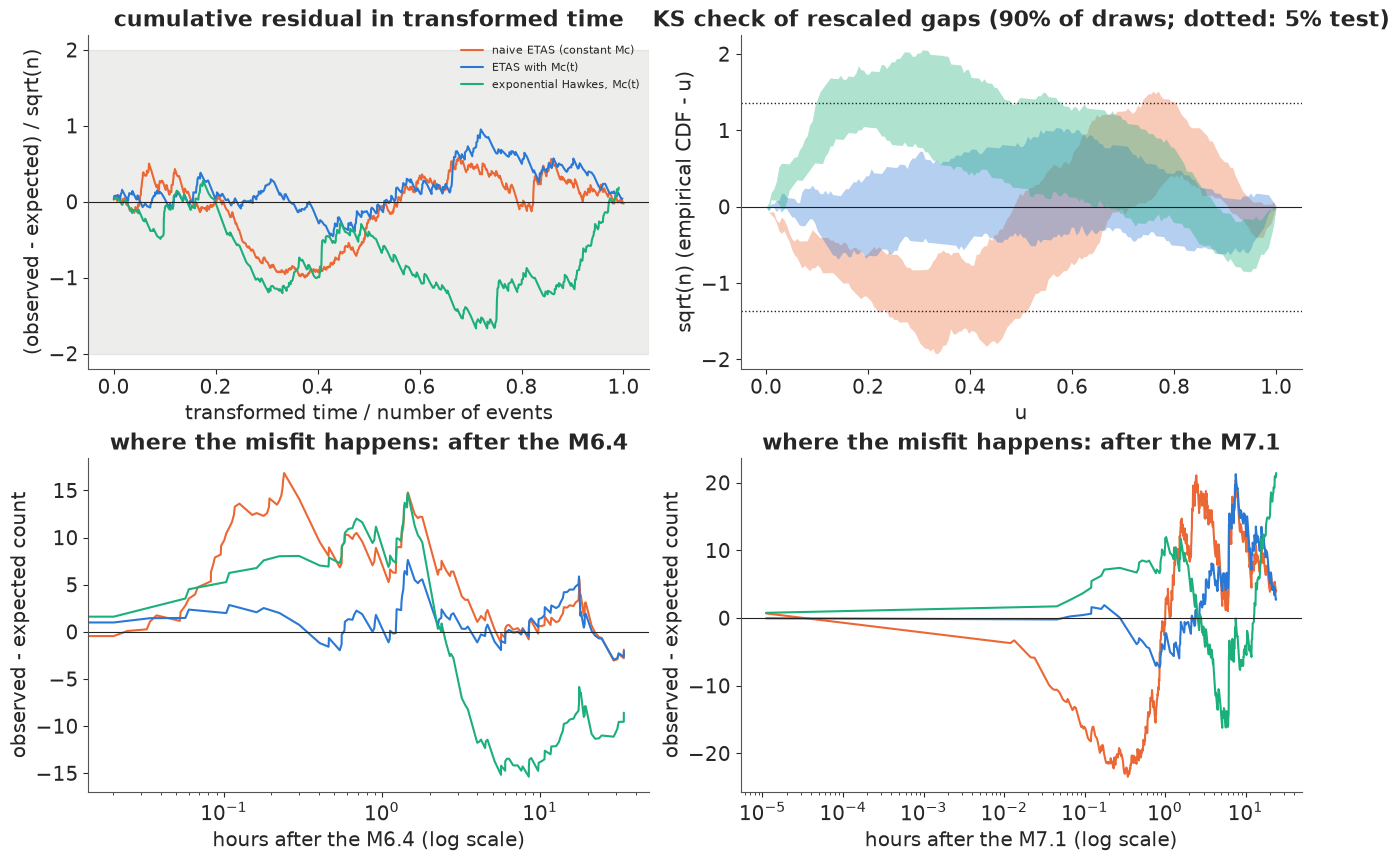

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
cols = {"naive ETAS (constant Mc)": ORANGE, "ETAS with Mc(t)": BLUE, "exponential Hawkes, Mc(t)": AQUA}
for label, r in resid.items():
    n_ = len(r["tgt"])
    tau_med = np.median(r["tau"], 0)
    res_count = np.arange(1, n_ + 1) - tau_med                 # observed - expected count
    axes[0, 0].plot(tau_med / n_, res_count / np.sqrt(n_), color=cols[label], lw=1.5, label=label)
    grid_u = np.linspace(0, 1, 200)
    ec = np.array([np.searchsorted(u, grid_u) / n_ for u in r["u"]])
    lo_, hi_ = np.quantile((ec - grid_u) * np.sqrt(n_), [0.05, 0.95], axis=0)
    axes[0, 1].fill_between(grid_u, lo_, hi_, color=cols[label], alpha=0.35, lw=0, label=label)
    # where in real time? residual count restarted at each mainshock
    tt_ = tB[r["tgt"]]
    for ax, (a, b_) in zip(axes[1], [(t64, 0.0), (0.0, T_B)]):
        sel = (tt_ >= a) & (tt_ < b_)
        base = res_count[np.searchsorted(tt_, a) - 1]
        ax.plot((tt_[sel] - a) * 24, res_count[sel] - base, color=cols[label], lw=1.5)
axes[0, 0].axhspan(-2, 2, color=GREY, alpha=0.15)
axes[0, 0].axhline(0, color=INK, lw=0.8)
axes[0, 0].set(xlabel="transformed time / number of events", ylabel="(observed - expected) / sqrt(n)",
               title="cumulative residual in transformed time")
axes[0, 0].legend(fontsize=8)
axes[0, 1].axhline(0, color=INK, lw=0.8)
for y in (-1.36, 1.36):
    axes[0, 1].axhline(y, color=INK, ls=":", lw=1)
axes[0, 1].set(xlabel="u", ylabel="sqrt(n) (empirical CDF - u)",
               title="KS check of rescaled gaps (90% of draws; dotted: 5% test)")
for ax, what in zip(axes[1], ["M6.4", "M7.1"]):
    ax.axhline(0, color=INK, lw=0.8)
    ax.set(xscale="log", xlabel=f"hours after the {what} (log scale)", ylabel="observed - expected count",
           title=f"where the misfit happens: after the {what}")

Top left: the cumulative residual (observed minus expected number of events, in units of
$\sqrt{n}$) against transformed time. Top right: the Kolmogorov-Smirnov check of the rescaled gaps
across posterior draws, scaled so that the 5% test is the dotted line for every model. Bottom:
the same residual in real time, restarted at each mainshock.

The cumulative residual alone does not separate the models - all three stay inside the loose
$\pm 2\sqrt{n}$ band. The distribution of the gaps does. The $M_c(t)$ ETAS model passes (median
KS distance about half the critical value; 2% of draws rejected), while the naive model (82%) and
the exponential Hawkes model (79%) are rejected for most posterior draws. The bottom panels show
where:

- **naive**: in the first half hour after the M7.1 it expects about 20 more events than were
  recorded - the events the network missed - and then catches up. After the M6.4, where M3s were
  missing only for minutes, its long $c$ makes it expect too few events in the first hour.
- **exponential Hawkes**: it expects about 15 more events than were recorded from about 3 hours
  after the M6.4 onwards (a single time scale cannot follow a $1/t$ decay) and swings after the M7.1.
- **$M_c(t)$ ETAS**: its largest excursion, about 20 events some hours after the M7.1, is about one
  $\sqrt{n}$, and the KS check does not flag it.

## 9 · Who triggered whom? Branching structure and the branching ratio

Given the parameters, every event's intensity splits into a background part and one part per
earlier event, so each event has a probability of being background and a probability of having
been triggered by each earlier event:

$$P(\text{parent of } i = j) = \frac{K_0 e^{\alpha(m_j - M_c)}(t_i - t_j + c)^{-p}}{\lambda(t_i)},
\qquad P(i \text{ is background}) = \frac{\mu}{\lambda(t_i)} .$$

**Stochastic declustering** (Zhuang, Ogata & Vere-Jones 2002) samples one parent per event from
these probabilities, for many posterior draws, and follows the family trees. Two questions: was the
M7.1 itself an aftershock of the M6.4, and how much of the sequence descends from which event?

In [16]:
seq_idx = np.flatnonzero(tB >= t64 - 0.05)               # the sequence, from just before the M6.4
j64, j71 = int(np.argmin(np.abs(tB - t64))), int(np.argmin(np.abs(tB)))
par_draws = params_list(main, 200, 2)
drng = np.random.default_rng(9)
cat_names = ["background", "earlier events (foreshocks, older)", "M6.4 family (not via the M7.1)", "M7.1 family"]
lineage = np.zeros((len(par_draws), len(seq_idx), 4))
parent71 = np.zeros((len(par_draws), j71 + 1))        # column 0..j71-1: earlier events; last: background
anc64_of_71 = np.zeros(len(par_draws))
for d_, par in enumerate(par_draws):
    ea = np.exp(par["alpha"] * (mB - MC))
    contrib = par["K0"] * g_kernel(tB[seq_idx][:, None] - tB[None, :], par, "omori") * ea
    probs = np.concatenate([contrib, np.full((len(seq_idx), 1), par["mu"])], axis=1)
    probs /= probs.sum(1, keepdims=True)
    k71 = np.searchsorted(seq_idx, j71)
    parent71[d_, :j71] = probs[k71, :j71]; parent71[d_, j71] = probs[k71, -1]
    u = drng.uniform(size=(len(seq_idx), 1))
    par_of = np.minimum((np.cumsum(probs, 1) < u).sum(1), len(tB))  # index into tB; len(tB) = background
    has64 = np.zeros(len(tB), bool); has71 = np.zeros(len(tB), bool); isbg = np.zeros(len(tB), bool)
    for k, i in enumerate(seq_idx):
        pj = par_of[k]
        if pj == len(tB):
            isbg[i] = True
            continue
        has64[i] = pj == j64 or has64[pj]
        has71[i] = pj == j71 or has71[pj]
    anc64_of_71[d_] = has64[j71]
    lin = np.select([isbg[seq_idx], has71[seq_idx], has64[seq_idx]], [0, 3, 2], default=1)
    lineage[d_, np.arange(len(seq_idx)), lin] = 1
p_bg71 = parent71[:, -1].mean()
top = np.argsort(parent71[:, :-1].mean(0))[::-1][:8]
print(f"P(the M7.1 was a background event) = {p_bg71:.4f}")
print(f"P(the M6.4 is among the M7.1's ancestors) = {anc64_of_71.mean():.2f}")
print(f"P(the M6.4 is the M7.1's DIRECT parent) = {parent71[:, j64].mean():.2f}")

P(the M7.1 was a background event) = 0.0001
P(the M6.4 is among the M7.1's ancestors) = 0.99
P(the M6.4 is the M7.1's DIRECT parent) = 0.02


branching ratio: median 0.70, 90% interval 0.45-1.19, P(n >= 1) = 0.12; alpha < beta in 0.90 of draws
share of sequence events (M6.4 onwards, up to the origin) by lineage: {'background': np.float64(0.001), 'earlier events (foreshocks, older)': np.float64(0.002), 'M6.4 family (not via the M7.1)': np.float64(0.213), 'M7.1 family': np.float64(0.784)}


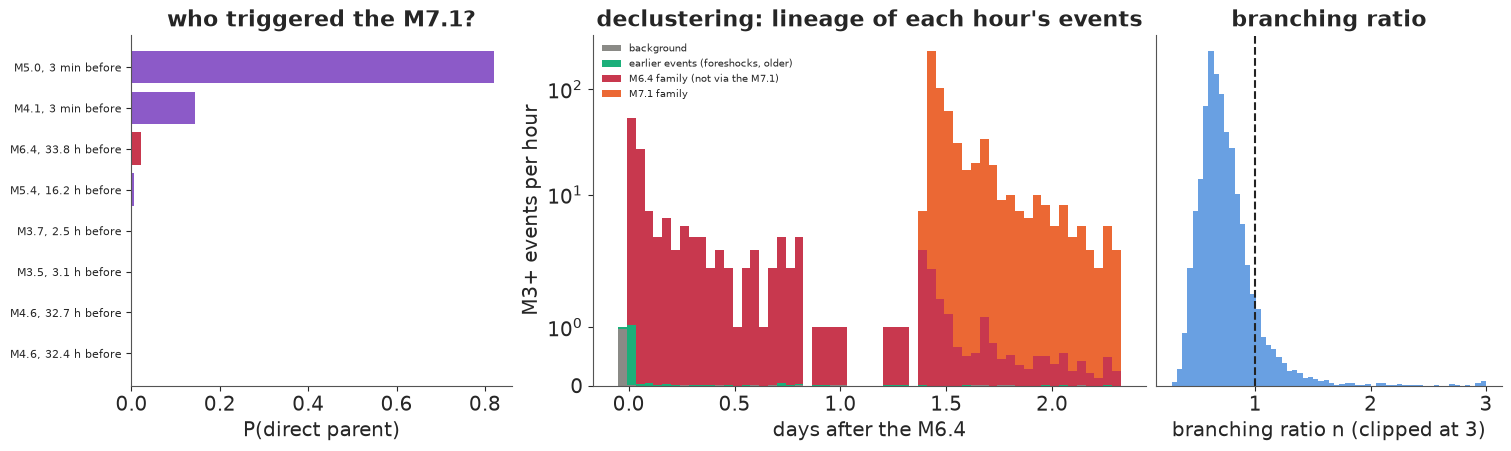

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), width_ratios=[1.1, 1.6, 1])
ax = axes[0]
pp = parent71[:, top].mean(0)
dt_h = (tB[j71] - tB[top]) * 24
lab_ = [f"M{mB[j]:.1f}, " + (f"{h * 60:.0f} min" if h < 1 else f"{h:.1f} h") + " before" for j, h in zip(top, dt_h)]
ax.barh(range(len(top))[::-1], pp, color=[RED if j == j64 else PURPLE for j in top])
ax.set_yticks(range(len(top))[::-1], lab_, fontsize=8)
ax.set(xlabel="P(direct parent)", title="who triggered the M7.1?")
ax = axes[1]
edges = np.arange(t64 - 0.05, T_B + 1e-9, 1 / 24)
ts_seq = tB[seq_idx]
kbin = np.clip(np.digitize(ts_seq, edges) - 1, 0, len(edges) - 2)
counts = np.zeros((len(edges) - 1, 4))
mean_lin = lineage.mean(0)
for c_ in range(4):
    counts[:, c_] = np.bincount(kbin, weights=mean_lin[:, c_], minlength=len(edges) - 1)
ax.stackplot(edges[:-1] - t64, counts.T, colors=[GREY, AQUA, RED, ORANGE], labels=cat_names, step="post")
ax.set(yscale="symlog", xlabel="days after the M6.4", ylabel="M3+ events per hour",
       title="declustering: lineage of each hour's events")
ax.legend(fontsize=7, loc="upper left")
ax = axes[2]
bB = main.posterior
n_post = branching_ratio(bB["k1"].values.ravel(), bB["c"].values.ravel(), bB["p"].values.ravel(),
                         bB["alpha"].values.ravel(), bB["b"].values.ravel() * np.log(10))
ax.hist(np.clip(n_post, 0, 3), bins=60, color=BLUE, alpha=0.7)
ax.axvline(1, color=INK, ls="--")
ax.set(xlabel="branching ratio n (clipped at 3)", yticks=[], title="branching ratio")
print(f"branching ratio: median {np.median(n_post):.2f}, 90% interval "
      f"{np.quantile(n_post, 0.05):.2f}-{np.quantile(n_post, 0.95):.2f}, P(n >= 1) = {np.mean(n_post >= 1):.2f}; "
      f"alpha < beta in {np.mean(bB['alpha'].values < bB['b'].values * np.log(10)):.2f} of draws")
print("share of sequence events (M6.4 onwards, up to the origin) by lineage:",
      dict(zip(cat_names, np.round(mean_lin.mean(0), 3))));

**Was the M7.1 an aftershock of the M6.4?** In the ETAS sense, almost certainly: the probability
that it was a background event is about $10^{-4}$, because 34 hours after an M6.4 the triggered
rate dwarfs the background of the quiet years. But its **direct** parent was probably not the
M6.4 (probability 0.02): it was the M5.0 that struck three minutes before it (about 0.8), or the
M4.1 two and a half minutes before it (about 0.15). A small event a few minutes earlier contributes
more intensity than a big one 34 hours earlier. Those two were themselves in the M6.4's family, so
the M6.4 is an ancestor of the M7.1 with probability 0.99. "The M6.4 was a foreshock" is a
statement about this family tree, and it is only knowable in hindsight.

The middle panel colours each hour's events by expected lineage (symmetric log scale). The
M6.4's family (red) fills the first 34 hours; once the M7.1 strikes, its family (orange) makes up
almost everything, about 78% of the sequence up to the forecast origin against 21% for the rest
of the M6.4's family. Background events are about 0.1%.

**The branching ratio** (right) has a posterior median of about 0.7, with a long right tail: about
one draw in ten has $n \ge 1$ (printed). The tail comes from $\alpha$ being close to $\beta$ (in
about 10% of draws $\alpha > \beta$), when the average productivity is dominated by the rare largest
events. For a forecast of one week this is not a contradiction - $n$ is about infinite time, and a
near-critical process still produces finite counts in 7 days - but it gives the forecast a long
right tail.

## 10 · The forecast: the week after the M7.1, and what happened

Forecast origin: **7 July 2019, 03:20 UTC**, 24 hours after the M7.1. For each of 1,000 posterior
draws we simulate the next 7 days: the remaining aftershocks of every catalogued event, the
background, and every later generation, with magnitudes from Gutenberg-Richter. This is the
posterior predictive distribution of the future catalogue: it carries parameter uncertainty
(through the draws) and the randomness of the cascade (through the simulation). Simulations are
capped at 200,000 events; a draw that hits the cap is counted as "exploded".

The catalogue after that origin was held out of every fit. We compare with it at the end.

In [18]:
T_END = T_B + 7.0
obs = cat[(cat.mag >= MC) & (cat.t > T_B) & (cat.t <= T_END)]
grid_f = np.linspace(T_B, T_END, 169)
MAG_LEVELS = np.round(np.arange(3.0, 7.61, 0.1), 1)


def forecast(idata, hist, T0, T1, n=1000, seed=0, kernel="omori"):
    frng = np.random.default_rng(seed)
    out = dict(N=[], cum=[], maxm=[], exploded=[])
    for par in params_list(idata, n, seed, kernel):
        tt, mm, ex = simulate_etas(par, hist.t.values, hist.mag.values, T0, T1, MC, frng, kernel=kernel)
        out["N"].append(tt.size); out["exploded"].append(ex)
        out["cum"].append(np.searchsorted(tt, np.linspace(T0, T1, 169)))
        out["maxm"].append(mm.max() if mm.size else MC - 1)
        out.setdefault("N4", []).append((mm >= 4).sum())
    return {k: np.array(v) for k, v in out.items()}


fc = {label: forecast(fits[label], evB, T_B, T_END, seed=11, kernel=spec[1])
      for label, spec in model_specs.items()}
rows = []
for label, f in fc.items():
    rows.append({"model": label,
                 "M3+ count, median (90%)": f"{np.median(f['N']):.0f} ({np.quantile(f['N'], 0.05):.0f}-{np.quantile(f['N'], 0.95):.0f})",
                 "M4+ count, median (90%)": f"{np.median(f['N4']):.0f} ({np.quantile(f['N4'], 0.05):.0f}-{np.quantile(f['N4'], 0.95):.0f})",
                 "P(M >= 5)": round(np.mean(f["maxm"] >= 5), 2), "P(M >= 6)": round(np.mean(f["maxm"] >= 6), 3),
                 "P(M >= 7.1)": round(np.mean(f["maxm"] >= 7.1), 3), "exploded draws": int(f["exploded"].sum())})
rows.append({"model": "what happened", "M3+ count, median (90%)": f"{len(obs)}",
             "M4+ count, median (90%)": f"{int((obs.mag >= 4).sum())}",
             "P(M >= 5)": f"largest M{obs.mag.max():.1f}", "P(M >= 6)": "-", "P(M >= 7.1)": "-", "exploded draws": "-"})
display(pd.DataFrame(rows).set_index("model"))

,"M3+ count, median (90%)","M4+ count, median (90%)",P(M >= 5),P(M >= 6),P(M >= 7.1),exploded draws
model,,,,,,
naive ETAS (constant Mc),284 (123-29547),38 (12-4035),0.92,0.426,0.117,31
ETAS with Mc(t),230 (151-566),20 (9-53),0.76,0.127,0.012,0
"exponential Hawkes, Mc(t)",5 (1-33),0 (0-4),0.08,0.012,0.001,0
what happened,191,12,largest M4.9,-,-,-


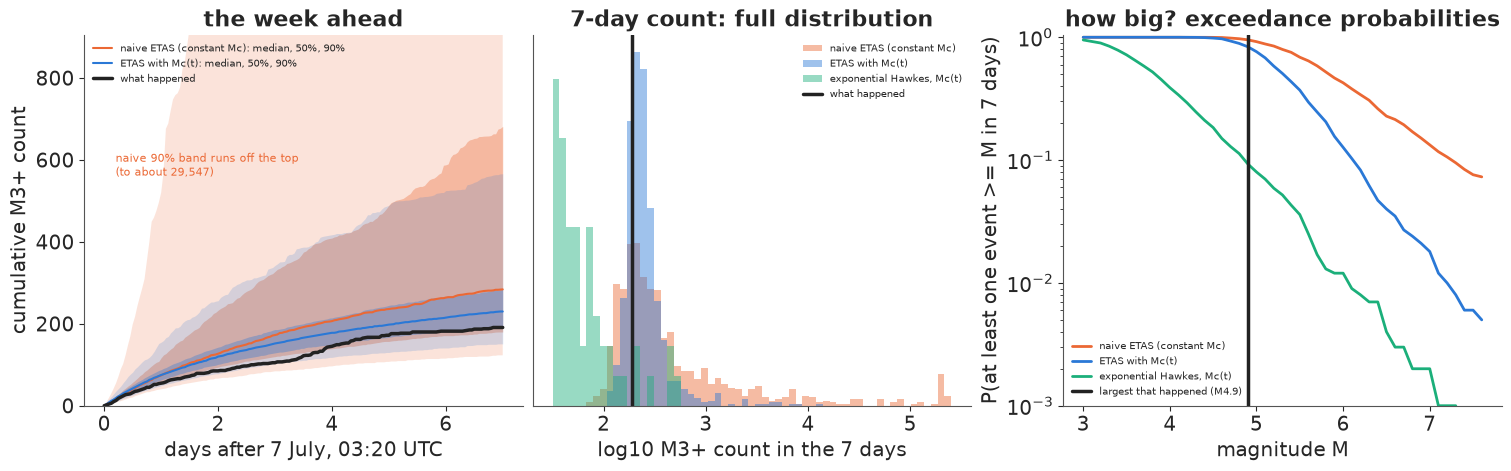

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
ax = axes[0]
days = grid_f - T_B
obs_cum = np.searchsorted(obs.t.values, grid_f)
for label in ["naive ETAS (constant Mc)", "ETAS with Mc(t)"]:
    cc = fc[label]["cum"]
    for qlo, qhi, a in [(0.05, 0.95, 0.18), (0.25, 0.75, 0.35)]:
        ax.fill_between(days, np.quantile(cc, qlo, 0), np.quantile(cc, qhi, 0), color=cols[label], alpha=a, lw=0)
    ax.plot(days, np.median(cc, 0), color=cols[label], lw=1.5, label=f"{label}: median, 50%, 90%")
ax.plot(days, obs_cum, color=INK, lw=2.5, label="what happened")
ymax = np.quantile(fc["ETAS with Mc(t)"]["cum"][:, -1], 0.95) * 1.6
ax.text(0.2, ymax * 0.62, "naive 90% band runs off the top\n(to about "
        f"{np.quantile(fc['naive ETAS (constant Mc)']['cum'][:, -1], 0.95):,.0f})", color=ORANGE, fontsize=8)
ax.set(xlabel="days after 7 July, 03:20 UTC", ylabel="cumulative M3+ count",
       title="the week ahead", ylim=(0, ymax))
ax.legend(fontsize=7, loc="upper left")
ax = axes[1]
for label in model_specs:
    x = np.log10(np.maximum(fc[label]["N"], 1))
    ax.hist(x, bins=np.linspace(1.5, 5.4, 60), color=cols[label], alpha=0.45, label=label, density=True)
ax.axvline(np.log10(len(obs)), color=INK, lw=2.5, label="what happened")
ax.set(xlabel="log10 M3+ count in the 7 days", yticks=[], title="7-day count: full distribution")
ax.legend(fontsize=7)
ax = axes[2]
for label in model_specs:
    pexc = [(fc[label]["maxm"] >= lv).mean() for lv in MAG_LEVELS]
    ax.plot(MAG_LEVELS, pexc, color=cols[label], lw=2, label=label)
ax.axvline(obs.mag.max(), color=INK, lw=2.5, label=f"largest that happened (M{obs.mag.max():.1f})")
ax.set(yscale="log", ylim=(1e-3, 1.05), xlabel="magnitude M", ylabel="P(at least one event >= M in 7 days)",
       title="how big? exceedance probabilities")
ax.legend(fontsize=7);

**The forecast with $M_c(t)$** (blue) put the week's M3+ count at a median of about 230, with a
90% interval of roughly 150-570, and M4+ at about 20 (roughly 10-55); nutpie is not
bit-reproducible, so the last digits move between runs. What happened: 191 M3+ and 12 M4+, both
inside the intervals and below the medians - the sequence decayed a little faster than the model
expected (left, black line in the lower half of the blue band). It gave an M5 or larger a
probability of about 0.75 and an M6 or larger about 0.13; the largest event that actually
happened was an M4.9. "No M5" was the less likely outcome, but not a surprising one (about 1 in
4); one week of one sequence cannot tell whether 0.75 was too high.

**The naive forecast** (orange) shows what a lower b-value and a lower $\alpha$ (hence a larger
share of productive large events) do. Its median count is similar, but its 90% interval reaches
about 30,000 M3+ events, 31 of 1,000 draws hit the simulation cap, and it gives an event larger
than the M7.1 a probability of about 0.12 within a week, ten times the $M_c(t)$ model's 0.01. That
is not a cautious forecast; it is a wrong one, produced by the catalogue's missing small events.

**The exponential Hawkes forecast** (green) is far too low: with a memory of an hour and a half,
the M7.1's aftershocks are almost over by the origin, and it predicts a median of 5 M3+ events for
a week that had 191.

The fairest single number for comparing forecasts is the **log-likelihood of what happened** in
the held-out week: the point-process log-likelihood of the observed events and magnitudes in
(origin, origin + 7 days], evaluated sequentially (each event's intensity uses all earlier events,
including earlier held-out ones), averaged over the posterior on the probability scale.

In [20]:
def heldout_loglik(idata, T0, T1, kernel, n=400, seed=5):
    ev = cat[(cat.mag >= MC) & (cat.t <= T1)]
    t, m = ev.t.values, ev.mag.values
    w = t > T0
    lls = []
    for par in params_list(idata, n, seed, kernel):
        lam = intensity(t[w], t, m, par, kernel)
        comp = par["mu"] * (T1 - T0) + par["K0"] * (np.exp(par["alpha"] * (m - MC)) *
                                                     (Gk(T1 - t, par, kernel) - Gk(T0 - t, par, kernel))).sum()
        be = par["beta"]
        lmag = np.log(be) - be * (m[w] - MC) - np.log(-np.expm1(-be * (MMAX - MC)))
        lls.append(np.log(lam).sum() - comp + lmag.sum())
    lls = np.array(lls)
    return np.log(np.mean(np.exp(lls - lls.max()))) + lls.max(), w.sum()


ho = {label: heldout_loglik(fits[label], T_B, T_END, spec[1]) for label, spec in model_specs.items()}
ref = ho["ETAS with Mc(t)"][0]
display(pd.DataFrame({"held-out log-likelihood": {k: round(v[0], 1) for k, v in ho.items()},
                      "difference to ETAS with Mc(t)": {k: round(v[0] - ref, 1) for k, v in ho.items()},
                      "per event": {k: round((v[0] - ref) / v[1], 3) for k, v in ho.items()}}))

,held-out log-likelihood,difference to ETAS with Mc(t),per event
naive ETAS (constant Mc),450.7,-7.5,-0.039
ETAS with Mc(t),458.2,0.0,0.000
"exponential Hawkes, Mc(t)",406.6,-51.6,-0.270


On the held-out week the $M_c(t)$ ETAS model scores best: the naive model is about 7 nats worse
and the exponential Hawkes model about 50 nats worse (table). The ranking agrees with the
time-rescaling checks of section 8, which used only data before the origin. (The naive model's
deficit is modest because its parameters describe days 1-8, when the catalogue is complete,
reasonably well; its damage is in the tails of the forecast.)

## 11 · The forecast nobody wanted to be right: the week after the M6.4

Rewind to **12 hours after the M6.4** (5 July, 05:34 UTC). Nobody knew an M7.1 was 22 hours away.
Refit the ETAS model with $M_c(t)$ on the data available then, and ask the same question: how
likely is an event at least as large as the M6.4 within a week? With only half a day of
aftershocks, the priors (which encode what typical sequences look like) carry more weight.

In [21]:
T_A = t64 + 0.5
evA = cat[(cat.mag >= MC) & (cat.t <= T_A)]
steps_A = mc_steps(S0, T_A, MC, [(t64, 6.4)])
modA, tgA = etas_model(evA.t.values, evA.mag.values, MC, S0, T_A, steps=steps_A)
fitA = pm.sample(model=modA, random_seed=RANDOM_SEED, progressbar=False)
print(f"origin A: {len(evA)} events ({int((evA.t >= t64).sum())} since the M6.4), {len(tgA)} in the likelihood; "
      f"divergences {int(fitA.sample_stats['diverging'].sum())}, max r_hat "
      f"{float(az.rhat(fitA, var_names=VARS).to_dataset().to_dataarray().max()):.3f}")
display(az.summary(fitA, var_names=VARS, round_to=3))
fcA = forecast(fitA, evA, T_A, T_A + 7, seed=12)
pA = {lv: np.mean(fcA["maxm"] >= lv) for lv in [5.0, 6.0, 6.4, 7.0]}
print("P(at least one event >= M in the next 7 days):", {f"M{k}": round(v, 3) for k, v in pA.items()},
      f"| exploded draws: {int(fcA['exploded'].sum())}")

origin A: 151 events (120 since the M6.4), 122 in the likelihood; divergences 0, max r_hat 1.002


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,0.020,0.004,0.013,0.027,3983.942,2563.688,1.000,0.000,0.000
c,0.003,0.002,0.000,0.008,2264.235,2421.283,1.001,0.000,0.000
p,1.135,0.097,0.990,1.295,1845.714,1988.968,1.001,0.002,0.002
alpha,2.268,0.168,2.010,2.544,737.549,893.717,1.002,0.006,0.005
b,0.955,0.079,0.832,1.085,3213.792,2659.757,1.001,0.001,0.001
k1,0.084,0.036,0.036,0.146,748.145,776.498,1.002,0.001,0.001


P(at least one event >= M in the next 7 days): {'M5.0': np.float64(0.516), 'M6.0': np.float64(0.124), 'M6.4': np.float64(0.075), 'M7.0': np.float64(0.033)} | exploded draws: 18


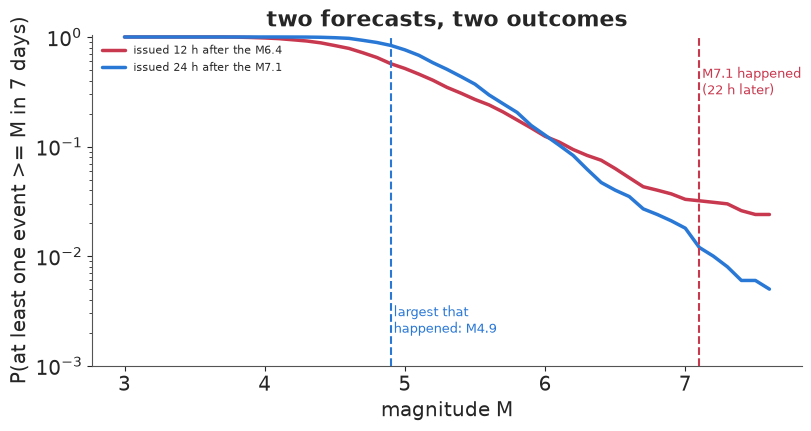

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.2))
pexcA = [(fcA["maxm"] >= lv).mean() for lv in MAG_LEVELS]
pexcB = [(fc["ETAS with Mc(t)"]["maxm"] >= lv).mean() for lv in MAG_LEVELS]
ax.plot(MAG_LEVELS, pexcA, color=RED, lw=2.5, label="issued 12 h after the M6.4")
ax.plot(MAG_LEVELS, pexcB, color=BLUE, lw=2.5, label="issued 24 h after the M7.1")
ax.axvline(7.1, color=RED, ls="--", lw=1.5); ax.text(7.12, 0.3, "M7.1 happened\n(22 h later)", color=RED, fontsize=9)
ax.axvline(4.9, color=BLUE, ls="--", lw=1.5); ax.text(4.92, 0.002, "largest that\nhappened: M4.9", color=BLUE, fontsize=9)
ax.set(yscale="log", ylim=(1e-3, 1.05), xlabel="magnitude M", ylabel="P(at least one event >= M in 7 days)",
       title="two forecasts, two outcomes");
ax.legend(fontsize=8);

Twelve hours after the M6.4 the model gave an event of M6.4 or more within a week a probability
of about 7%, and an M7 or more about 3% (printed). A few percent is the usual order of magnitude
for the chance that a large earthquake is followed by a larger one soon after, which is why a
few percent of large earthquakes turn out, in hindsight, to have been foreshocks. Forecasts of
this kind were issued during the sequence (e.g. the UCERF3-ETAS forecasts of Milner et al.
2020); ours is a much simpler, purely temporal cousin. The M7.1 then happened.

Was the forecast wrong? A 3-7% event happening once is not evidence against a 3-7% forecast;
only many sequences can test that (the Collaboratory for the Study of Earthquake Predictability
runs such tests). The two curves also cross in an instructive way: after the M7.1 the model knew
more ($b$, $\alpha$, $p$ from several hundred events) and gave lower probabilities to the very largest
magnitudes, while half a day after the M6.4 the upper tail is still mostly the prior's view of
typical sequences ($b$ was 0.96 $\pm$ 0.08 then, against 1.07 $\pm$ 0.05 later).

## What to tell the public on 7 July

From the $M_c(t)$ ETAS fit at the forecast origin, with parameter and cascade uncertainty:

- **Many felt earthquakes will continue.** Expect about 150 to 600 M3+ earthquakes in the region
  this week, of them roughly 10 to 50 of M4+.
- **An M5 or larger is likely** (about 3 in 4), **an M6 or larger is possible** (about 1 in 8),
  and **an earthquake larger than Saturday's M7.1 is unlikely but not impossible** (about 1 in
  100).
- The rate falls day by day. (What happened: 191 M3+, 12 M4+, the largest an M4.9 - the lower
  half of the forecast range.)

And what not to do: fit a catalogue as if it were complete in the hours after a mainshock. The
naive model, with clean diagnostics, would have told the public that an earthquake larger than the
M7.1 had about a one-in-eight chance that week.

## Summary

- A **Hawkes/ETAS** process is a Poisson process in which every event adds a decaying bump to the
  rate; its **branching ratio** says how many events each one triggers and whether the process is
  stable. Its likelihood is $\sum\log\lambda - \int\lambda$ with a closed-form compensator.
- The $O(n^2)$ parent sum is the cost. The exponential kernel has an $O(n)$ recursion; the
  power law, written as a **mixture of exponentials** with fixed nodes, gets an $O(nK)$ one that
  matches the exact likelihood to $10^{-5}$ at a ninth of the cost.
- **Short-term incompleteness** after a mainshock biased $c$, $p$, $\alpha$ and the b-value in a
  known-truth simulation and on Ridgecrest, and fattened the tail of the naive forecast tenfold. A
  likelihood with a **time-varying completeness threshold** fixed it, with only the compensator
  changing.
- The **time-rescaling theorem** checks the fit without simulation, and located the failures.
- **Stochastic declustering** answers "who triggered whom" probabilistically: the M7.1 was part of
  the M6.4's family, most likely triggered directly by an M5.0 three minutes earlier.
- **Forecasts** are posterior predictive simulations of cascades. They should be scored on
  held-out data with a proper score, and a single rare outcome (the M7.1) is not a verdict.

## Try it yourself

1. **Space.** Add a spatial kernel (e.g. an isotropic power law in distance scaled by
   $10^{0.5 m}$) to make the model spatio-temporal, and forecast where M4+ events will occur.
   Which part of the likelihood becomes expensive now, and does the mixture-of-exponentials trick
   still help?
2. **Many origins.** Refit at 3, 7 and 30 days after the M7.1 and forecast the following week each
   time. Compute the probability integral transform of the observed count for each forecast: are
   the forecasts calibrated, or systematically high as the first one was? What happens to $p$ and
   the branching ratio as the window grows?
3. **Another self-exciting system.** Fit the exponential and power-law Hawkes models to a
   different point process - e.g. the timestamps of M7+ earthquakes worldwide from E24, or trade
   times of a stock - and compare branching ratios. Is anything there as close to critical as an
   aftershock sequence?